# **Density Functional Theory**
### Tutorial — Marco Fronzi

This tutorial introduces the core principles of Density Functional Theory (DFT) and walks through a working implementation using only standard Python libraries (NumPy, SciPy). The goal is clarity over efficiency: every step — from building basis functions to running the self-consistent field (SCF) loop — is written explicitly so the physics is visible in the code.

The implementation uses Slater-type orbital (STO) basis functions, numerical grid integration, a local density approximation (LDA) exchange-correlation functional, and canonical orthogonalisation to solve the Kohn-Sham equations iteratively.


<center >======================================================================================================================================== </center>

 ##  <center>  **Hohenberg-Kohn Theorem** </center>
DFT is grounded in the Hohenberg-Kohn theorems, asserting that the ground state properties of a many-electron system are uniquely determined by its electron density. The total energy 
E of an interacting many-body system in DFT is formulated as:


$ E[\rho^0] = T[\rho^0] + E_{\text{int}}[\rho^0] + V_{\text{ext}}[\rho^0] $    


- $( \rho^0 )$ denotes the real electron density of the ground state.
- $T[\rho^0]$ represents the kinetic energy for a system of interacting electrons with density $( \rho )$.
- $E_{\text{int}}[\rho^0]$  interaction energy in an interacting electron system
- $V_{\text{ext}}[\rho^0] $ is the external potential energy, often due to the nuclei.

NOTE: $E_{\text{int}}[\rho^0]$ is the same functional for any system of interacting particles

$$(E_{\text{H}}[\rho] + E_{\text{xc}}[\rho]) = E_{\text{int}}[\rho])$$



<!-- $$ V_{\text{eff}}(\mathbf{r}) = V_{\text{ext}}(\mathbf{r}) + V_{\text{H}}(\mathbf{r}) + V_{\text{xc}}(\mathbf{r}) $$ -->
<!-- 
In this expression:

- $V_{\text{ext}}(\mathbf{r})$ is the external potential, usually originating from the atomic nuclei.
- $V_{\text{H}}(\mathbf{r})$, the Hartree potential, represents the classical electrostatic potential due to the electron density.
- $V_{\text{xc}}(\mathbf{r})$ is the exchange-correlation potential, which is the functional derivative of the exchange-correlation energy with respect to the electron density: $$ V_{\text{xc}}(\mathbf{r}) = \frac{\delta E_{\text{xc}}[\rho]}{\delta \rho(\mathbf{r})} $$

The Kohn-Sham orbitals, $\psi_i(\mathbf{r})$, are solutions to these equations and are used to construct the electron density, $\rho(\mathbf{r})$, through the relation: 
$$ \rho(\mathbf{r}) = \sum_{i=1}^{N=occ} |\psi_i(\mathbf{r})|^2 $$

Here, $N$ is the number of electrons in the system, assuming each orbital is occupied by one electron. The set of Kohn-Sham equations is solved self-consistently, meaning the orbitals are used to calculate the density, which in turn is used to update the effective potential, and this process is iterated until convergence is reached. -->



## **Kohn-Sham Equations**

The Kohn-Sham (KS) approach maps the interacting many-electron problem onto a fictitious system of non-interacting electrons that reproduce the same ground-state density. The KS total energy functional is:

$$E_{KS}[\rho] = T_s[\rho] + E_H[\rho] + E_{xc}[\rho] + V_{\text{ext}}[\rho]$$

where:
- $T_s[\rho]$ is the kinetic energy of the non-interacting reference system
- $E_H[\rho] = \frac{1}{2}\int\int \frac{\rho(\mathbf{r}_1)\rho(\mathbf{r}_2)}{|\mathbf{r}_1-\mathbf{r}_2|}d\mathbf{r}_1 d\mathbf{r}_2$ is the Hartree (classical Coulomb) energy
- $E_{xc}[\rho]$ is the exchange-correlation energy (all quantum many-body effects)
- $V_{\text{ext}}[\rho] = -\sum_I Z_I \int \frac{\rho(\mathbf{r})}{|\mathbf{r}-\mathbf{R}_I|}d\mathbf{r}$ is the nuclear attraction

The effective single-particle KS Hamiltonian is:

$$\hat{H}_{KS} = -\frac{1}{2}\nabla^2 + V_{\text{eff}}(\mathbf{r}), \quad V_{\text{eff}} = V_{\text{ext}} + V_H + V_{xc}$$

Solving $\hat{H}_{KS}\psi_i = \varepsilon_i\psi_i$ for all occupied orbitals and rebuilding $\rho(\mathbf{r}) = \sum_i^{occ}|\psi_i(\mathbf{r})|^2$ is repeated until self-consistency.


The variation of the ground-state energy $(\delta E)$ vanishes, and with the normalization constraint on the auxiliary functions $$\delta \left( E_{KS}[n] - \epsilon_i \int dr \psi_i^{\sigma*}(r) \psi_i^\sigma(r) - 1 \right) = 0$$, we have:

$$
\delta E_{KS} = \left(-\frac{1}{2}\nabla^2 \psi_i^\sigma(r) + \left(V_{ext}(r) + \frac{\delta E_H[n]}{\delta n(r,\sigma)} + \frac{\delta E_{xc}[n]}{\delta n(r,\sigma)}\right) \psi_i^\sigma(r)\right) = \epsilon_i \psi_i^\sigma(r)
$$

with respect to $\delta \psi_i^{\sigma*}(r)$, where $(\delta n(r,\sigma) = \psi_i^\sigma(r)$ and we have defined the spin density $n(r, \uparrow) + n(r, \downarrow) = n(r)$

The resulting one-electron Schrödinger equation can be exactly solved! The problem is that the functional $E_{xc}$ is not known (and not simple). It may not be invertible for systems with very degenerate ground states (like the paramagnetic Mott insulator with degeneracy $(2^N)$.

<center >======================================================================================================================================== </center>



##  <center>  **Expansion of Kohn-Sham Orbitals**  </center>

The Kohn-Sham orbitals $\psi_i(\mathbf{r})$ can be expanded in terms of a basis set $\{\chi_\mu(\mathbf{r})\}$ as:

### $$   \psi_i(\mathbf{r}) = \sum_{\mu} C_{\mu i} \chi_\mu(\mathbf{r}) $$

### Rewriting the Kohn-Sham Equations

Substituting this expansion into the Kohn-Sham equations, we get:

$ \left( -\frac{1}{2} \nabla^2 + V_{\text{eff}}(\mathbf{r}) \right) \left( \sum_{\mu} C_{\mu i} \chi_\mu(\mathbf{r}) \right) = \varepsilon_i \left( \sum_{\mu} C_{\mu i} \chi_\mu(\mathbf{r}) \right) $


### Gaussian-Type STO Basis Functions

The basis functions $\chi_\mu(\mathbf{r})$ in a Gaussian-type STO basis set are expressed as:

$ \chi_\mu(\mathbf{r}) = N_\mu r^{n_\mu - 1} e^{-\alpha_\mu r^2} Y_{l_\mu}^{m_\mu}(\theta, \phi) $

where:

- $ N_{\mu} $ is the normalization constant.
- $( r )$ is the radial distance from the nucleus.
- $n_\mu$ is the principal quantum number of the basis function.
- $ \alpha_\mu $ is the Gaussian exponent, determining the width of the Gaussian function.
- $ Y_{l_\mu}^{m_\mu}(\theta, \phi) $ are the spherical harmonics, which depend on the angular coordinates $\theta$ and $\phi$, and are characterized by the angular momentum quantum numbers $ l_\mu $ and $ m_\mu $.

Kohn-Sham equantions become:

To rewrite the Kohn-Sham equations using the explicit form of the Gaussian-type STO basis functions $ \chi_\mu(\mathbf{r}) $, we first recall the expansion of the Kohn-Sham orbitals $ \psi_i(\mathbf{r}) $ in terms of these basis functions:

$\psi_i(\mathbf{r}) = \sum_{\mu} C_{\mu i} \chi_\mu(\mathbf{r}) $

where $ \chi_\mu(\mathbf{r}) = N_\mu r^{n_\mu - 1} e^{-\alpha_\mu r^2} Y_{l_\mu}^{m_\mu}(\theta, \phi) $.

Substituting this into the Kohn-Sham equation, we get:

$ \left( -\frac{1}{2} \nabla^2 + V_{\text{eff}}(\mathbf{r}) \right) \left( \sum_{\mu} C_{\mu i} N_\mu r^{n_\mu - 1} e^{-\alpha_\mu r^2} Y_{l_\mu}^{m_\mu}(\theta, \phi) \right) = \varepsilon_i \left( \sum_{\mu} C_{\mu i} N_\mu r^{n_\mu - 1} e^{-\alpha_\mu r^2} Y_{l_\mu}^{m_\mu}(\theta, \phi) \right) $

This equation represents the Kohn-Sham equations with the orbitals expanded in terms of Gaussian-type STO basis functions. Each term in the sum over \( \mu \) represents a basis function, and the coefficients \( C_{\mu i} \) are to be determined by solving these equations.



### Basis Function Form (STO-type)

The basis functions implemented here are **Slater-type orbitals** approximated by single Gaussians:

$$\phi_\mu(\mathbf{r}) = R_\mu(r) \cdot Y_{l_\mu}^{m_\mu}(\theta, \phi)$$

The radial part depends on the orbital type:

**s orbitals** ($l=0$):
$$R(r) = e^{-\alpha r}$$

**p and higher orbitals** ($l \geq 1$):
$$R(r) = r^l \cdot e^{-\alpha r} \cdot L_{n-l-1}^{2l+1}(2\alpha r)$$

where $\alpha$ is the Slater exponent, $Y_l^m$ are real spherical harmonics, and $L$ is the generalised Laguerre polynomial.

Note: the class is named `GaussianBasisFunction` for historical reasons, but the radial decay is $e^{-\alpha r}$ (STO), not $e^{-\alpha r^2}$ (true Gaussian). This form better approximates atomic orbitals with a single exponent.


### Pre-SCF workflow at a glance (cells 6 - 29)
![Pre-SCF workflow at a glance (cells 6 - 29)](./notebook_steps/stage0_overview.png)

*Read this once before diving into the code. Every box below maps to one or two cells; the red bar at the bottom is where the SCF iteration begins.*


### Step 1: Build the framework (cells 6 - 7)
![Step 1: Build the framework (cells 6 - 7)](./pics/stage1_framework.png)

*Three classes wire the whole computation: Atom carries a nucleus, GaussianBasisFunction is one phi_mu, MolecularOrbital is the LCAO sum that yields psi_i. Helpers below the boxes generate the basis and seed the initial MOs.*


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import eigh
from scipy.special import sph_harm_y, genlaguerre

# ---------------------------------------------------------------------------
# Periodic table: element symbol -> atomic number Z
# ---------------------------------------------------------------------------
ELEMENTS = {
    "H": 1, "He": 2, "Li": 3, "Be": 4, "B": 5, "C": 6, "N": 7, "O": 8,
    "F": 9, "Ne": 10, "Na": 11, "Mg": 12, "Al": 13, "Si": 14, "P": 15,
    "S": 16, "Cl": 17, "Ar": 18, "K": 19, "Ca": 20,
    "Sc": 21, "Ti": 22, "V": 23, "Cr": 24, "Mn": 25, "Fe": 26, "Co": 27,
    "Ni": 28, "Cu": 29, "Zn": 30, "Ga": 31, "Ge": 32, "As": 33, "Se": 34,
    "Br": 35, "Kr": 36, "Rb": 37, "Sr": 38, "Y": 39, "Zr": 40,
    "Nb": 41, "Mo": 42, "Tc": 43, "Ru": 44, "Rh": 45, "Pd": 46,
    "Ag": 47, "Cd": 48, "In": 49, "Sn": 50, "Sb": 51, "Te": 52,
    "I": 53, "Xe": 54, "Cs": 55, "Ba": 56, "La": 57, "Ce": 58,
    "Pr": 59, "Nd": 60, "Pm": 61, "Sm": 62, "Eu": 63, "Gd": 64,
    "Tb": 65, "Dy": 66, "Ho": 67, "Er": 68, "Tm": 69, "Yb": 70,
    "Lu": 71, "Hf": 72, "Ta": 73, "W": 74, "Re": 75, "Os": 76,
    "Ir": 77, "Pt": 78, "Au": 79, "Hg": 80, "Tl": 81, "Pb": 82,
    "Bi": 83, "Po": 84, "At": 85, "Rn": 86, "Fr": 87, "Ra": 88,
    "Ac": 89, "Th": 90, "Pa": 91, "U": 92, "Np": 93, "Pu": 94,
    "Am": 95, "Cm": 96, "Bk": 97, "Cf": 98, "Es": 99, "Fm": 100,
    "Md": 101, "No": 102, "Lr": 103, "Rf": 104, "Db": 105,
    "Sg": 106, "Bh": 107, "Hs": 108, "Mt": 109, "Ds": 110,
    "Rg": 111, "Cn": 112, "Nh": 113, "Fl": 114, "Mc": 115,
    "Lv": 116, "Ts": 117, "Og": 118,
}


def get_atomic_number(element_symbol):
    # Returns the atomic number Z for an element symbol, or None if unknown.
    return ELEMENTS.get(element_symbol, None)


def define_basis_set_params():
    # Two basis sets are provided:
    #
    # 'SZ' (single-zeta, minimal)
    #   One Gaussian per occupied shell.  Fast but gives only 1 virtual orbital
    #   for many molecules, making the SCF trivially degenerate.
    #   Use only for quick tests or H2.
    #
    # 'DZ' (double-zeta, recommended)
    #   Two Gaussians per shell (inner + outer exponent), plus explicit 1s core
    #   for second-row atoms.  Gives adequate virtual space (n_virt >= n_occ)
    #   for any closed-shell molecule covered here.
    #
    # Format of each entry: (orbital_type, exponent, principal_n, angular_l)
    # p entries automatically generate m_l = -1, 0, +1 functions (3 per entry).
    #
    # Exponents are STO-type single Gaussians calibrated to reproduce the
    # qualitative shape of the corresponding atomic orbital.  They are
    # illustrative values for a tutorial, not production-quality.

    basis_params = {

        # ----------------------------------------------------------------
        # SZ: one Gaussian per shell (minimal, for quick checks only)
        # ----------------------------------------------------------------
        'SZ': {
            'H':  [('s', 1.24, 1, 0)],
            'He': [('s', 1.60, 1, 0)],
            'Li': [('s', 2.69, 2, 0)],
            'Be': [('s', 3.05, 2, 0)],
            'B':  [('s', 3.40, 2, 0), ('p', 2.80, 2, 1)],
            'C':  [('s', 3.75, 2, 0), ('p', 3.15, 2, 1)],
            'N':  [('s', 2.65, 2, 0), ('p', 2.05, 2, 1)],
            'O':  [('s', 2.75, 2, 0), ('p', 2.15, 2, 1)],
            'F':  [('s', 2.85, 2, 0), ('p', 2.25, 2, 1)],
            'Ne': [('s', 2.95, 2, 0), ('p', 2.35, 2, 1)],
        },

        # ----------------------------------------------------------------
        # DZ: double-zeta (recommended for proper SCF behaviour)
        #
        # Each occupied shell is split into inner (tight) + outer (diffuse)
        # exponents, plus an explicit core 1s for heavy atoms.
        # This ensures n_virt >= n_occ for all molecules listed here.
        #
        # n_basis per atom:
        #   H   -> 2   (2 x 1s)
        #   He  -> 2   (2 x 1s)
        #   Li  -> 3   (2 x 1s-core/val + 1 x 2s)
        #   C,N,O,F,Ne -> 2s + 2s + 2x3p = 2+2+6 = 10
        #
        # Molecule basis sizes and virtual space:
        #   H2   : 4    n_occ=1   n_virt=3
        #   H2O  : 14   n_occ=5   n_virt=9
        #   CH4  : 18   n_occ=5   n_virt=13
        #   N2   : 20   n_occ=7   n_virt=13
        #   CO   : 20   n_occ=7   n_virt=13
        #   NH3  : 16   n_occ=5   n_virt=11
        # ----------------------------------------------------------------
        'DZ': {
            # Hydrogen: two 1s Gaussians (inner + outer)
            'H': [
                ('s', 1.24, 1, 0),   # 1s inner
                ('s', 0.30, 1, 0),   # 1s outer (diffuse)
            ],
            # Helium: two 1s Gaussians
            'He': [
                ('s', 2.43, 1, 0),
                ('s', 0.80, 1, 0),
            ],
            # Lithium: core 1s + two valence 2s
            'Li': [
                ('s', 4.69, 1, 0),   # 1s core (tight)
                ('s', 2.69, 2, 0),   # 2s inner
                ('s', 0.64, 2, 0),   # 2s outer
            ],
            # Beryllium: core 1s + two valence 2s
            'Be': [
                ('s', 5.40, 1, 0),
                ('s', 3.05, 2, 0),
                ('s', 0.77, 2, 0),
            ],
            # Boron: core 1s + two valence 2s + two sets of 2p (x3)
            'B': [
                ('s', 5.30, 1, 0),
                ('s', 3.40, 2, 0),
                ('s', 0.88, 2, 0),
                ('p', 2.80, 2, 1),
                ('p', 0.72, 2, 1),
            ],
            # Carbon: core 1s + two valence 2s + two sets of 2p (x3)
            'C': [
                ('s', 5.70, 1, 0),   # 1s core
                ('s', 1.87, 2, 0),   # 2s inner valence
                ('s', 0.60, 2, 0),   # 2s outer valence
                ('p', 1.70, 2, 1),   # 2p inner valence (x3)
                ('p', 0.55, 2, 1),   # 2p outer valence (x3)
            ],
            # Nitrogen: core 1s + two valence 2s + two sets of 2p (x3)
            'N': [
                ('s', 6.79, 1, 0),
                ('s', 2.65, 2, 0),
                ('s', 0.84, 2, 0),
                ('p', 2.05, 2, 1),
                ('p', 0.67, 2, 1),
            ],
            # Oxygen: core 1s + two valence 2s + two sets of 2p (x3)
            'O': [
                ('s', 7.66, 1, 0),   # 1s core
                ('s', 2.75, 2, 0),   # 2s inner valence
                ('s', 0.84, 2, 0),   # 2s outer valence
                ('p', 2.15, 2, 1),   # 2p inner valence (x3)
                ('p', 0.83, 2, 1),   # 2p outer valence (x3)
            ],
            # Fluorine
            'F': [
                ('s', 8.65, 1, 0),
                ('s', 2.85, 2, 0),
                ('s', 0.95, 2, 0),
                ('p', 2.25, 2, 1),
                ('p', 0.90, 2, 1),
            ],
            # Neon
            'Ne': [
                ('s', 9.64, 1, 0),
                ('s', 2.95, 2, 0),
                ('s', 1.05, 2, 0),
                ('p', 2.35, 2, 1),
                ('p', 0.95, 2, 1),
            ],
            # Sodium: 1s core + 2s + 3s valence
            'Na': [
                ('s', 10.23, 1, 0),
                ('s', 3.10,  2, 0),
                ('s', 0.90,  3, 0),
                ('p', 2.00,  2, 1),
            ],
            # Silicon (example heavier atom)
            'Si': [
                ('s', 11.0,  1, 0),
                ('s', 3.40,  2, 0),
                ('s', 1.10,  3, 0),
                ('p', 3.50,  2, 1),
                ('p', 1.20,  3, 1),
            ],
            # Sulfur
            'S': [
                ('s', 12.0,  1, 0),
                ('s', 3.60,  2, 0),
                ('s', 1.20,  3, 0),
                ('p', 3.70,  2, 1),
                ('p', 1.40,  3, 1),
            ],
            # Chlorine
            'Cl': [
                ('s', 13.0,  1, 0),
                ('s', 3.70,  2, 0),
                ('s', 1.30,  3, 0),
                ('p', 3.80,  2, 1),
                ('p', 1.60,  3, 1),
            ],
        },
    }

    # Keep '6-31G' as an alias for 'SZ' for backward compatibility
    basis_params['6-31G'] = basis_params['SZ']
    return basis_params


In [3]:
# ---------------------------------------------------------------------------
# Core data structures
# ---------------------------------------------------------------------------

class Atom:
    # Represents a nucleus: element symbol and its Cartesian position (Angstrom).
    def __init__(self, element_symbol, position):
        self.element  = element_symbol
        self.position = np.array(position, dtype=float)   # stored as ndarray


class GaussianBasisFunction:
    # Single Gaussian-type STO centred on an atom.
    #
    # Parameters
    #   element_symbol : str
    #   center         : array-like (3,)  Cartesian coords (Angstrom)
    #   exponent       : float  Gaussian exponent alpha
    #   principal_n    : int    principal quantum number n
    #   angular_l      : int    angular momentum quantum number l
    #   magnetic_m     : int    magnetic quantum number m_l in [-l, l]
    #   orbital_type   : str    's', 'p', or 'd'

    def __init__(self, element_symbol, center, exponent,
                 principal_n, angular_l, magnetic_m, orbital_type='s'):
        self.element      = element_symbol
        self.center       = np.array(center, dtype=float)
        self.exponent     = exponent
        self.n            = principal_n
        self.l            = angular_l
        self.m_l          = magnetic_m
        self.orbital_type = orbital_type

    def _radial_factor(self, r):
        # Radial part of the STO-type basis function.
        if self.orbital_type == 's':
            return np.exp(-self.exponent * r)
        else:
            norm_arg = 2.0 * self.exponent * r
            laguerre = genlaguerre(self.n - self.l - 1, 2 * self.l + 1)(norm_arg)
            return r ** self.l * np.exp(-self.exponent * r) * laguerre

    def evaluate(self, point):
        # Evaluate phi(r) at a Cartesian point.
        # Returns the real part of R(r) * Y_l^{m_l}(theta, phi_angle).
        point     = np.asarray(point, dtype=float)
        diff      = point - self.center
        r         = np.linalg.norm(diff)
        if r < 1e-14:
            return 0.0            # avoid singularity at nucleus
        theta     = np.arccos(diff[2] / r)
        phi_angle = np.arctan2(diff[1], diff[0])
        radial    = self._radial_factor(r)
        angular   = sph_harm_y(self.l, self.m_l, theta, phi_angle)
        return float(radial * angular.real)

    def squared_evaluate(self, point):
        return self.evaluate(point) ** 2


# ---------------------------------------------------------------------------
# Molecular orbital: LCAO of Gaussian basis functions
# ---------------------------------------------------------------------------

class MolecularOrbital:
    # psi_i(r) = sum_mu  C_{mu,i} * phi_mu(r)
    #
    # Parameters
    #   basis_functions : list of GaussianBasisFunction
    #   mo_coeffs       : ndarray (n_basis,)  expansion coefficients C_{mu,i}

    def __init__(self, basis_functions, mo_coeffs):
        self.basis_functions = basis_functions
        self.mo_coeffs       = np.asarray(mo_coeffs, dtype=float)

    def evaluate(self, point):
        # Return psi_i(r) at a Cartesian point.
        return sum(c * bf.evaluate(point)
                   for bf, c in zip(self.basis_functions, self.mo_coeffs))

    def squared_evaluate(self, point):
        return self.evaluate(point) ** 2


# ---------------------------------------------------------------------------
# Basis-set construction
# ---------------------------------------------------------------------------

def generate_atomic_orbitals(molecule_geometry, basis_params, basis_set_name):
    # Build a flat list of GaussianBasisFunction objects for the whole molecule.
    #
    # Parameters
    #   molecule_geometry : list of (element_symbol, position) tuples
    #   basis_params      : dict from define_basis_set_params()
    #   basis_set_name    : str  e.g. '6-31G'
    #
    # Returns  list of GaussianBasisFunction

    basis_functions = []
    for element_symbol, position in molecule_geometry:
        if element_symbol not in basis_params[basis_set_name]:
            raise ValueError(
                f"Basis set '{basis_set_name}' has no entry for '{element_symbol}'.")
        for (orb_type, exponent, principal_n, angular_l) in basis_params[basis_set_name][element_symbol]:
            for magnetic_m in range(-angular_l, angular_l + 1):
                bf = GaussianBasisFunction(
                    element_symbol, position, exponent,
                    principal_n, angular_l, magnetic_m, orb_type)
                basis_functions.append(bf)
    return basis_functions


# ---------------------------------------------------------------------------
# Initial-guess MO coefficients (seed for the SCF loop)
# ---------------------------------------------------------------------------

def initialize_molecular_orbitals(basis_functions, num_electrons, method='EHT'):
    # Produce an initial guess for the MO coefficient matrix C (n_basis x n_basis).
    #
    # Methods:
    #   'AO'  - identity (each MO = one AO)
    #   'EHT' - diagonalise a simple Huckel Hamiltonian
    #   'SAD' - random coefficients (placeholder for superposition of atomic densities)
    #
    # Returns
    #   mo_coeff_matrix : ndarray (n_basis, n_basis)  columns = MO coefficient vectors
    #   occupied_mos    : list of MolecularOrbital  (only the n_occ occupied orbitals)

    n_basis = len(basis_functions)

    if method == 'AO':
        mo_coeff_matrix = np.eye(n_basis)

    elif method == 'EHT':
        # Huckel matrix: diagonal = orbital energy, nearest-neighbour coupling
        huckel_matrix = np.zeros((n_basis, n_basis))
        for i in range(n_basis):
            huckel_matrix[i, i] = -0.5          # placeholder ionisation energy (Ha)
            if i + 1 < n_basis:
                huckel_matrix[i, i + 1] = 0.1   # placeholder coupling
                huckel_matrix[i + 1, i] = 0.1
        _, mo_coeff_matrix = np.linalg.eigh(huckel_matrix)

    elif method == 'SAD':
        rng             = np.random.default_rng(seed=0)
        mo_coeff_matrix = rng.random((n_basis, n_basis))

    else:
        raise ValueError(f"Unknown method '{method}'. Choose 'AO', 'EHT', or 'SAD'.")

    n_occ        = num_electrons // 2
    occupied_mos = [
        MolecularOrbital(basis_functions, mo_coeff_matrix[:, i])
        for i in range(n_occ)
    ]
    return mo_coeff_matrix, occupied_mos


# ---------------------------------------------------------------------------
# Grid construction utilities
# ---------------------------------------------------------------------------

def create_grid_points(x_range, y_range, z_range, n_points):
    # Return a flat (N, 3) array of Cartesian grid points.
    #   x_range, y_range, z_range : tuple (min, max)
    #   n_points : int  number of divisions per axis
    x = np.linspace(x_range[0], x_range[1], n_points)
    y = np.linspace(y_range[0], y_range[1], n_points)
    z = np.linspace(z_range[0], z_range[1], n_points)
    grid_points = np.array(np.meshgrid(x, y, z, indexing='ij')).T.reshape(-1, 3)
    return grid_points


def create_grid_point_mesh(x_range, y_range, z_range, n_points):
    # Return three 3-D meshgrid arrays (X, Y, Z) for volumetric plotting.
    x = np.linspace(x_range[0], x_range[1], n_points)
    y = np.linspace(y_range[0], y_range[1], n_points)
    z = np.linspace(z_range[0], z_range[1], n_points)
    return np.meshgrid(x, y, z, indexing='ij')


def generate_meshgrid(plane, x_range, y_range, n_points):
    # Return a 2-D meshgrid for the chosen coordinate plane.
    #   Returns axis1, axis2 (the two varying coordinates on that plane).
    ax = np.linspace(x_range[0], x_range[1], n_points)
    ay = np.linspace(y_range[0], y_range[1], n_points)
    if plane in ('xy', 'xz', 'yz'):
        return np.meshgrid(ax, ay)
    else:
        raise ValueError(f"Invalid plane '{plane}'. Choose 'xy', 'xz', or 'yz'.")


### Step 2: Choose molecule + basis (cell 8)
![Step 2: Choose molecule + basis (cell 8)](./pics/stage2_system.png)

*This single cell picks the system (NH3), chooses the basis (DZ), and computes the basis-function count, electron count, and shape of C. After this cell, you have atomic_orbitals, num_electrons, and an initial MO coefficient matrix.*


In [4]:
# ---------------------------------------------------------------------------
# Molecule geometry  (Cartesian coordinates in Angstrom)
# ---------------------------------------------------------------------------
# Uncomment a block to change the system.

# ── H2 ──────────────────────────────────────────────────────────────────────
# molecule_geometry = [
#     ('H', [-0.371, 0.0, 0.0]),
#     ('H', [ 0.371, 0.0, 0.0]),
# ]

# ── H2O (active) ─────────────────────────────────────────────────────────────
# molecule_geometry = [
#     ('O', [0.000000,  0.000000,  0.000000]),
#     ('H', [0.758602,  0.000000,  0.504284]),
#     ('H', [0.758602,  0.000000, -0.504284]),
# ]

# ── NH3 ──────────────────────────────────────────────────────────────────────
molecule_geometry = [
    ('N', [ 0.000000,  0.000000,  0.116490]),
    ('H', [ 0.000000,  0.939830, -0.271810]),
    ('H', [ 0.813831, -0.469910, -0.271810]),
    ('H', [-0.813831, -0.469910, -0.271810]),
]

# ── N2 ───────────────────────────────────────────────────────────────────────
# molecule_geometry = [
#     ('N', [-0.550, 0.0, 0.0]),
#     ('N', [ 0.550, 0.0, 0.0]),
# ]

# ── CH4 ──────────────────────────────────────────────────────────────────────
# molecule_geometry = [
#     ('C', [ 0.0000,  0.0000,  0.0000]),
#     ('H', [ 0.6276,  0.6276,  0.6276]),
#     ('H', [ 0.6276, -0.6276, -0.6276]),
#     ('H', [-0.6276,  0.6276, -0.6276]),
#     ('H', [-0.6276, -0.6276,  0.6276]),
# ]

# ---------------------------------------------------------------------------
# Basis set selection
# ---------------------------------------------------------------------------
# 'DZ' (double-zeta) is required for proper SCF behaviour on any molecule
# heavier than H2.  'SZ' (or legacy '6-31G') gives only 1 virtual orbital
# for most molecules, making the SCF trivially degenerate (converges in 1 step
# regardless of the starting density).
#
# Rule of thumb: n_virt should be >= n_occ for meaningful SCF iteration.
# DZ satisfies this for all molecules in the list above.

basis_set_name  = 'DZ'
basis_params    = define_basis_set_params()

# Full list of Gaussian basis functions for the molecule
atomic_orbitals = generate_atomic_orbitals(molecule_geometry, basis_params, basis_set_name)

# Total electron count (sum of atomic numbers Z)
num_electrons   = sum(get_atomic_number(sym) for sym, _ in molecule_geometry)

# Atom objects (needed in nuclear-attraction and nuclear-repulsion integrals)
atoms           = [Atom(sym, pos) for sym, pos in molecule_geometry]

# ---------------------------------------------------------------------------
# Initial MO coefficient matrix (EHT seed for the SCF)
# ---------------------------------------------------------------------------
init_method     = 'EHT'   # options: 'AO', 'EHT', 'SAD'

mo_coeff_matrix, occupied_molecular_orbitals = initialize_molecular_orbitals(
    atomic_orbitals, num_electrons, method=init_method)

n_occ  = num_electrons // 2
n_virt = len(atomic_orbitals) - n_occ

print(f"Molecule        : {[s for s, _ in molecule_geometry]}")
print(f"Total electrons : {num_electrons}")
print(f"Basis functions : {len(atomic_orbitals)}")
print(f"Occupied MOs    : {n_occ}")
print(f"Virtual MOs     : {n_virt}  {'(OK)' if n_virt >= n_occ else '(WARNING: too few virtuals - use DZ basis)'}")
print(f"MO coeff shape  : {mo_coeff_matrix.shape}")

if n_virt < 2:
    print("\n  WARNING: n_virt < 2 means the SCF has no degrees of freedom.")
    print("  Switch to basis_set_name = 'DZ' for meaningful SCF iteration.")


Molecule        : ['N', 'H', 'H', 'H']
Total electrons : 10
Basis functions : 15
Occupied MOs    : 5
Virtual MOs     : 10  (OK)
MO coeff shape  : (15, 15)


### Step 3: Extended-Huckel initial C (cells 8 - 9)
![Step 3: Extended-Huckel initial C (cells 8 - 9)](./notebook_steps/stage3_initial_C.png)

*Cell 8's call to initialize_molecular_orbitals(..., method='EHT') builds a tridiagonal Huckel matrix and diagonalises it to produce a starting C. Cell 9 prints it for inspection. This is NOT the answer; it is the seed the SCF will iterate from.*


In [5]:
# Inspect initial MO coefficient matrix
print("MO coefficient matrix (columns = MOs):\n", mo_coeff_matrix)
print("\nCoefficients of first occupied MO:\n",
      occupied_molecular_orbitals[0].mo_coeffs)


MO coefficient matrix (columns = MOs):
 [[-6.89748448e-02  1.35299025e-01 -1.96423740e-01 -2.50000000e-01
   2.93968901e-01 -3.26640741e-01  3.46759961e-01  3.53553391e-01
   3.46759961e-01  3.26640741e-01  2.93968901e-01  2.50000000e-01
   1.96423740e-01 -1.35299025e-01 -6.89748448e-02]
 [ 1.35299025e-01 -2.50000000e-01  3.26640741e-01  3.53553391e-01
  -3.26640741e-01  2.50000000e-01 -1.35299025e-01 -8.26072448e-17
   1.35299025e-01  2.50000000e-01  3.26640741e-01  3.53553391e-01
   3.26640741e-01 -2.50000000e-01 -1.35299025e-01]
 [-1.96423740e-01  3.26640741e-01 -3.46759961e-01 -2.50000000e-01
   6.89748448e-02  1.35299025e-01 -2.93968901e-01 -3.53553391e-01
  -2.93968901e-01 -1.35299025e-01  6.89748448e-02  2.50000000e-01
   3.46759961e-01 -3.26640741e-01 -1.96423740e-01]
 [ 2.50000000e-01 -3.53553391e-01  2.50000000e-01  7.96440891e-16
   2.50000000e-01 -3.53553391e-01  2.50000000e-01 -1.42496245e-16
  -2.50000000e-01 -3.53553391e-01 -2.50000000e-01  7.54945237e-16
   2.50000000e-

## Pre-SCF Visualisation: Basis Functions and Initial MOs

The plots below show the atomic orbital basis functions and the initial molecular orbitals constructed from the EHT guess, **before** the SCF loop runs. These give an intuition for the shape of the basis and the qualitative orbital mixing imposed by the Hückel seed. The converged HOMO, LUMO and charge density are visualised later, after the SCF.


### Step 4: Pre-SCF visualisations (cells 11 - 18)
![Step 4: Pre-SCF visualisations (cells 11 - 18)](./pics/stage4_visualise.png)

*Four plotting routines for sanity-checking the basis and the initial MOs: 2D atomic orbitals, 2D molecular orbitals, full 3D isosurfaces, and cutoff plots showing where each MO has significant amplitude.*


In [6]:
def plot_atomic_orbitals_2d(basis_functions, plane='xy',
                             x_range=(-2, 2), y_range=(-2, 2), n_points=100):
    # Plot each basis function and their pointwise sum on a chosen coordinate plane.
    #   plane       : 'xy' | 'xz' | 'yz'
    #   x_range, y_range : extent of the two plotted axes
    #   n_points    : grid resolution along each axis
    if not basis_functions:
        print("No basis functions to plot.")
        return

    axis1, axis2 = generate_meshgrid(plane, x_range, y_range, n_points)
    fixed_coord  = basis_functions[0].center  # fix the out-of-plane coord

    def eval_on_plane(bf):
        values = np.zeros(axis1.shape)
        it = np.nditer([axis1, axis2], flags=['multi_index'])
        while not it.finished:
            idx = it.multi_index
            a1, a2 = float(it[0]), float(it[1])
            if plane == 'xy':
                pt = [a1, a2, fixed_coord[2]]
            elif plane == 'xz':
                pt = [a1, fixed_coord[1], a2]
            else:                          # 'yz'
                pt = [fixed_coord[0], a1, a2]
            values[idx] = bf.evaluate(pt)
            it.iternext()
        return values

    n_plots = len(basis_functions) + 1    # individual BFs + total
    n_cols  = int(np.ceil(np.sqrt(n_plots)))
    n_rows  = int(np.ceil(n_plots / n_cols))
    ax_labels = {'xy': ('X (A)', 'Y (A)'),
                 'xz': ('X (A)', 'Z (A)'),
                 'yz': ('Y (A)', 'Z (A)')}[plane]

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5),
                             squeeze=False)
    axs = axs.ravel()

    total_values = np.zeros(axis1.shape)
    for i, bf in enumerate(basis_functions):
        bf_values     = eval_on_plane(bf)
        total_values += bf_values
        c = axs[i].pcolormesh(axis1, axis2, bf_values, shading='auto', cmap='bwr')
        axs[i].set_title(f'{bf.element}  {bf.orbital_type}-orbital')
        axs[i].set_xlabel(ax_labels[0])
        axs[i].set_ylabel(ax_labels[1])
        fig.colorbar(c, ax=axs[i])

    # Total (sum of all basis functions)
    c = axs[n_plots - 1].pcolormesh(axis1, axis2, total_values,
                                      shading='auto', cmap='bwr')
    axs[n_plots - 1].set_title('Total (sum of all basis functions)')
    axs[n_plots - 1].set_xlabel(ax_labels[0])
    axs[n_plots - 1].set_ylabel(ax_labels[1])
    fig.colorbar(c, ax=axs[n_plots - 1])

    for j in range(n_plots, len(axs)):
        axs[j].axis('off')
    plt.tight_layout()
    plt.show()


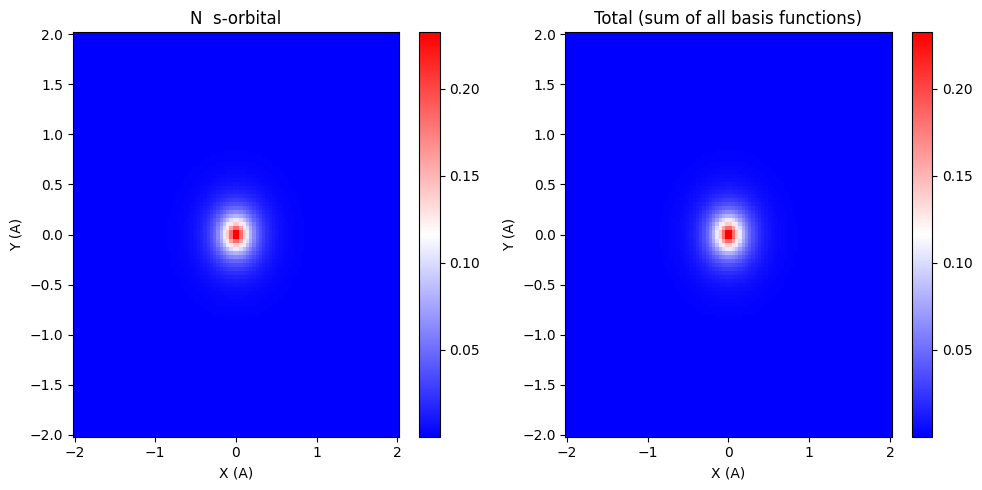

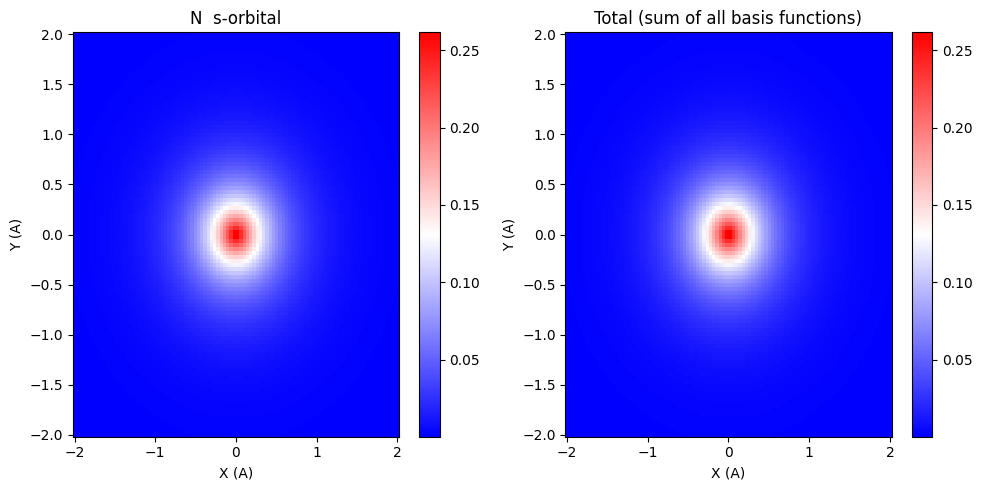

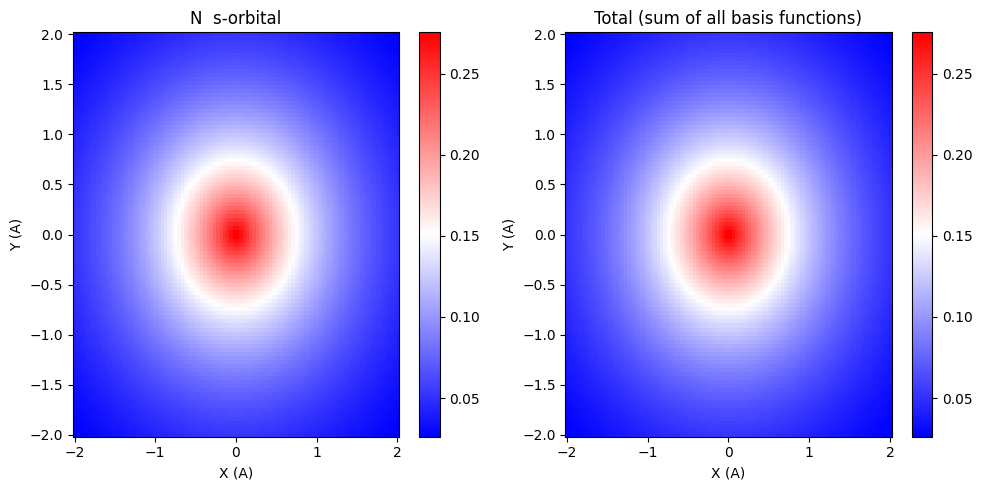

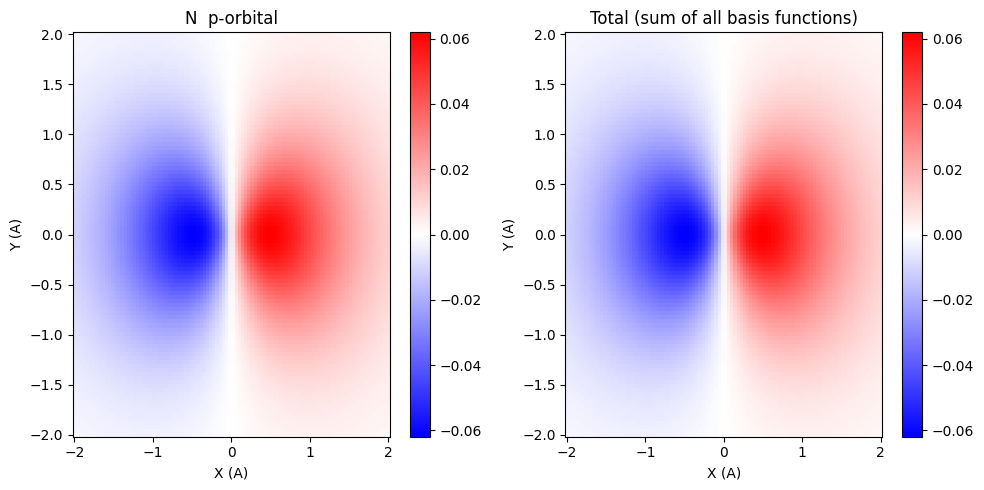

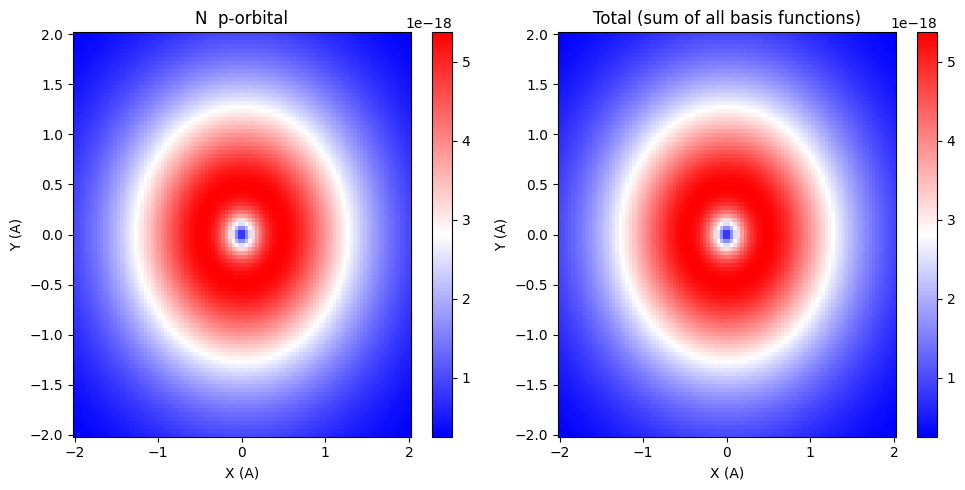

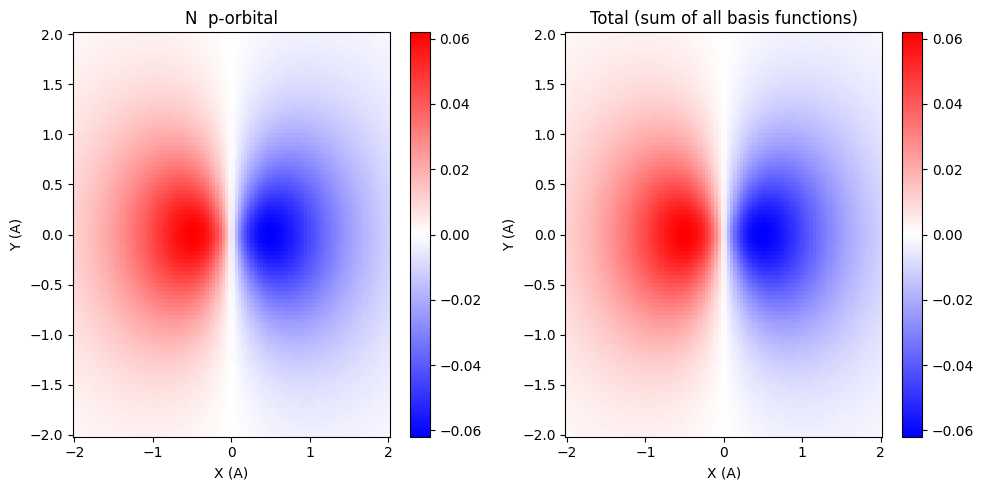

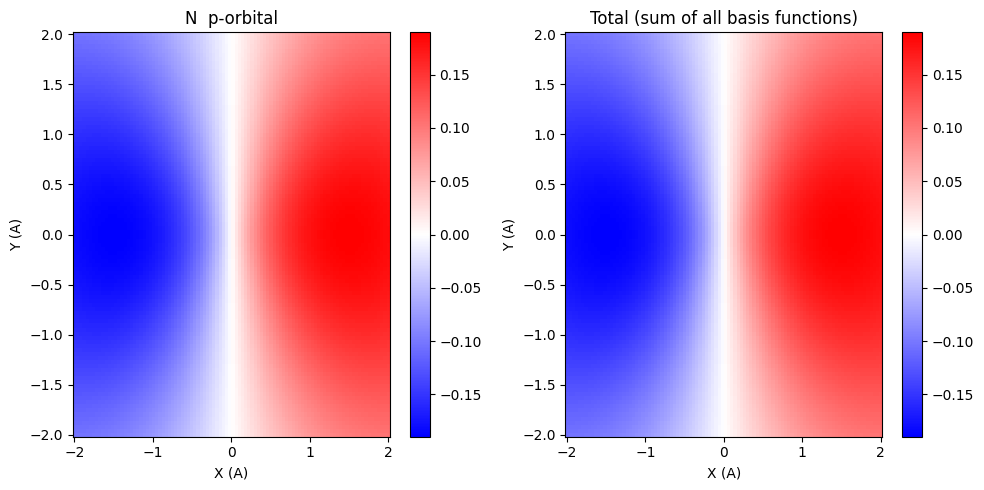

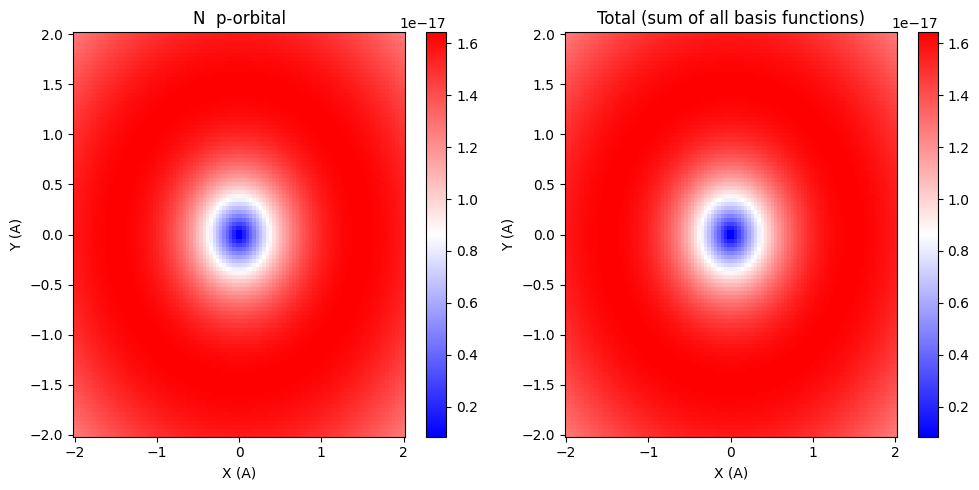

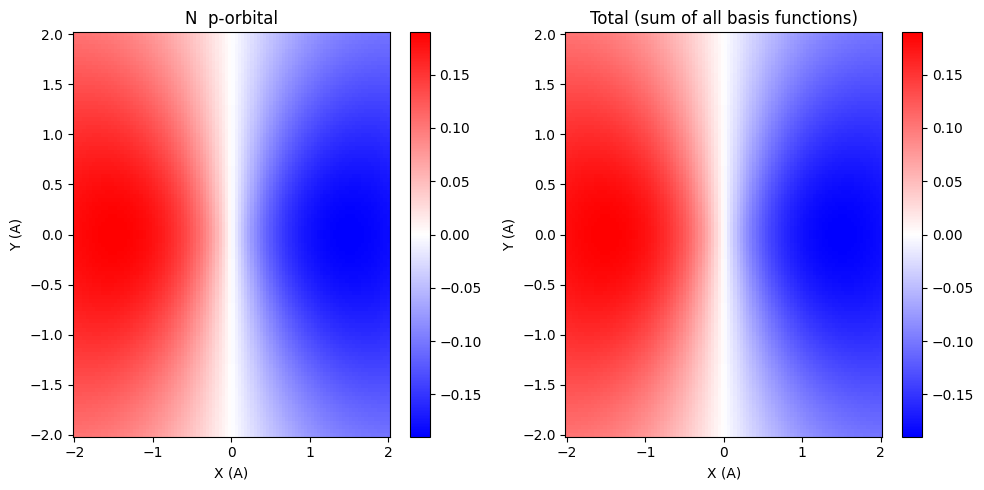

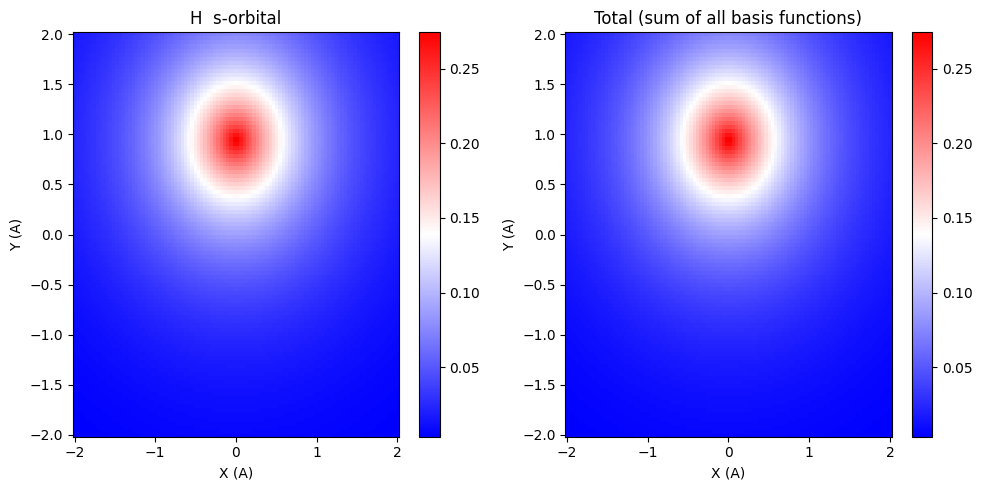

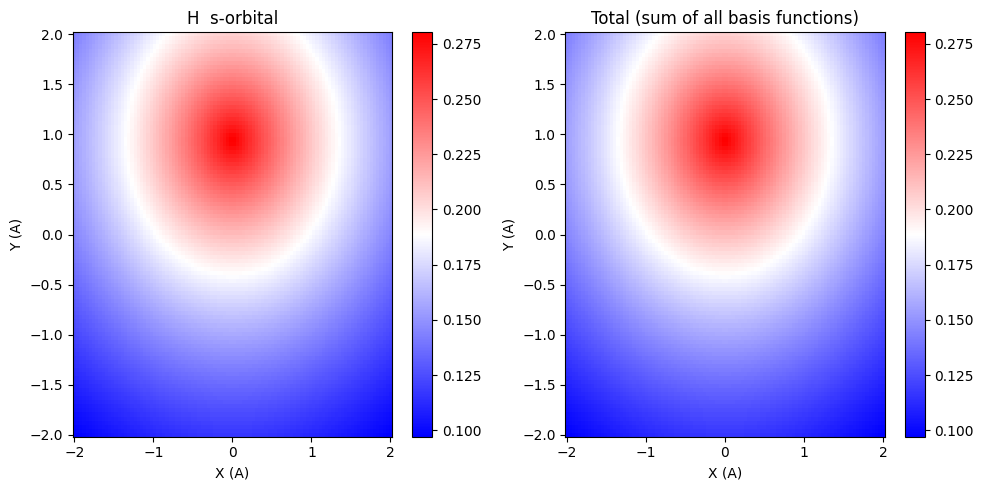

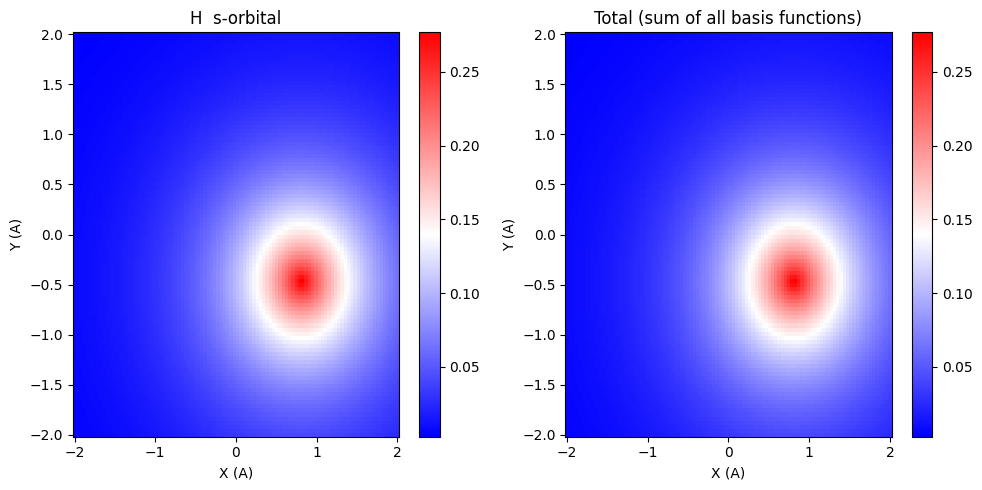

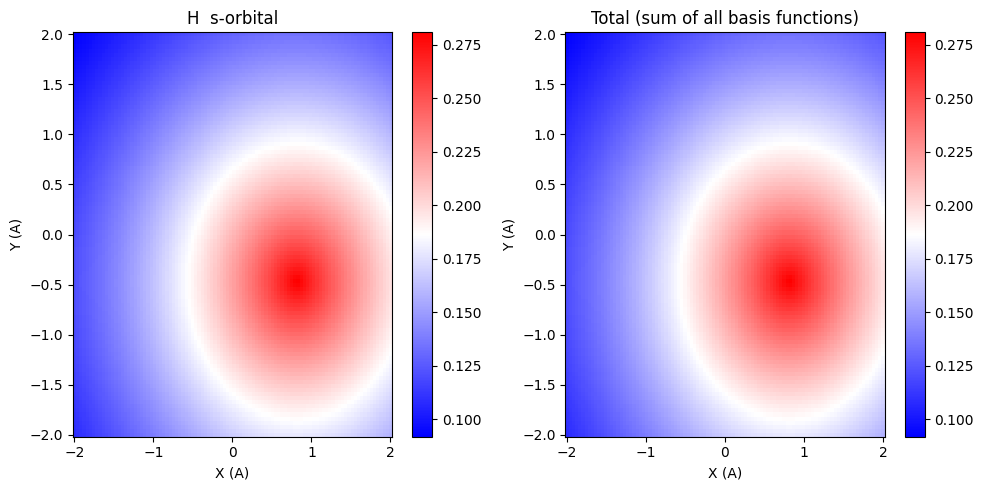

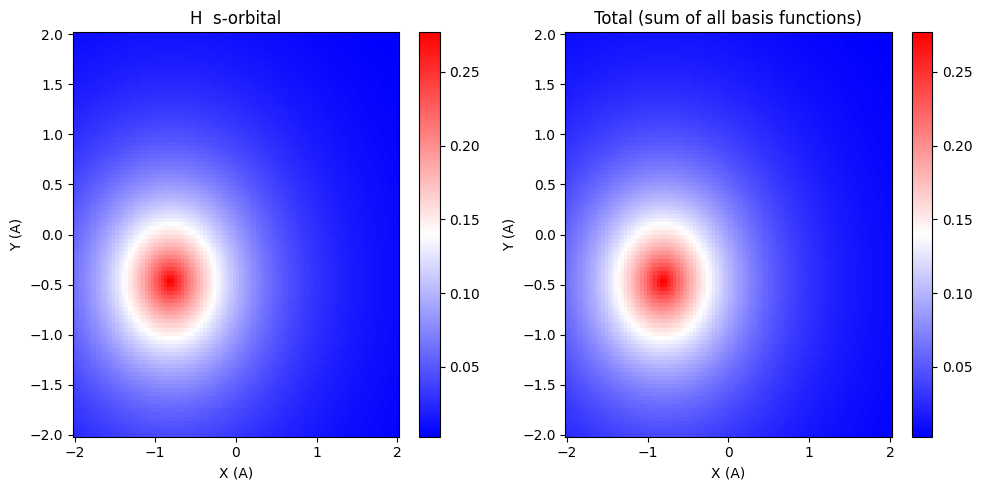

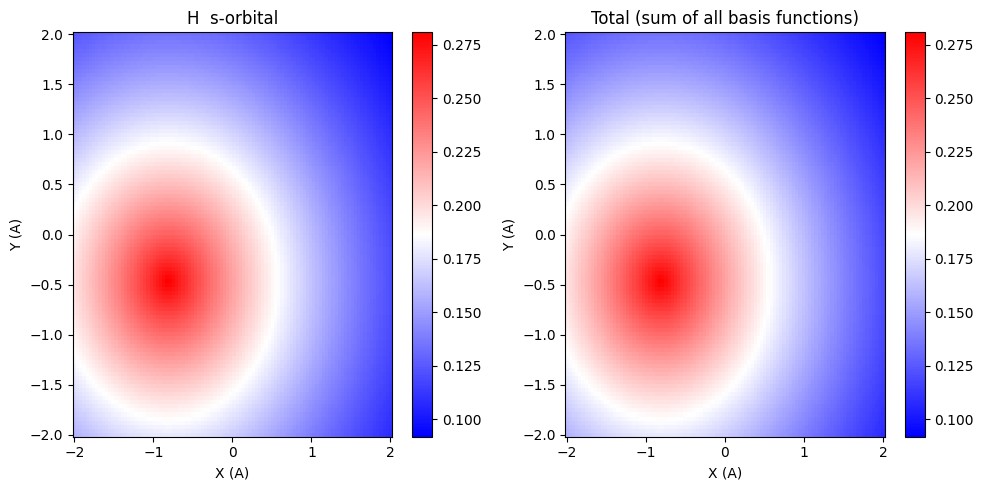

In [7]:
# Plot each basis function individually
for bf in atomic_orbitals:
    plot_atomic_orbitals_2d([bf], plane='xy', x_range=(-2, 2), y_range=(-2, 2), n_points=100)

In [8]:
def plot_molecular_orbitals_2d(molecular_orbitals, plane='xy',
                                x_range=(-2, 2), y_range=(-2, 2), n_points=100):
    # Plot each MO on the chosen coordinate plane.
    # The coordinate perpendicular to the plane is fixed to 0.
    if not molecular_orbitals:
        print("No molecular orbitals to plot.")
        return

    axis1, axis2 = generate_meshgrid(plane, x_range, y_range, n_points)
    n_mos  = len(molecular_orbitals)
    n_cols = int(np.ceil(np.sqrt(n_mos)))
    n_rows = int(np.ceil(n_mos / n_cols))
    ax_labels = {'xy': ('X (A)', 'Y (A)'),
                 'xz': ('X (A)', 'Z (A)'),
                 'yz': ('Y (A)', 'Z (A)')}[plane]

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5),
                             squeeze=False)
    axs = axs.ravel()

    for i, mo in enumerate(molecular_orbitals):
        mo_values = np.zeros(axis1.shape)
        it = np.nditer([axis1, axis2], flags=['multi_index'])
        while not it.finished:
            idx = it.multi_index
            a1, a2 = float(it[0]), float(it[1])
            if plane == 'xy':
                pt = [a1, a2, 0.0]
            elif plane == 'xz':
                pt = [a1, 0.0, a2]
            else:                     # 'yz'
                pt = [0.0, a1, a2]
            mo_values[idx] = mo.evaluate(pt)
            it.iternext()

        c = axs[i].pcolormesh(axis1, axis2, mo_values, shading='auto', cmap='bwr')
        axs[i].set_title(f'Molecular Orbital {i + 1}')
        axs[i].set_xlabel(ax_labels[0])
        axs[i].set_ylabel(ax_labels[1])
        fig.colorbar(c, ax=axs[i])

    for j in range(n_mos, len(axs)):
        axs[j].axis('off')
    plt.tight_layout()
    plt.show()


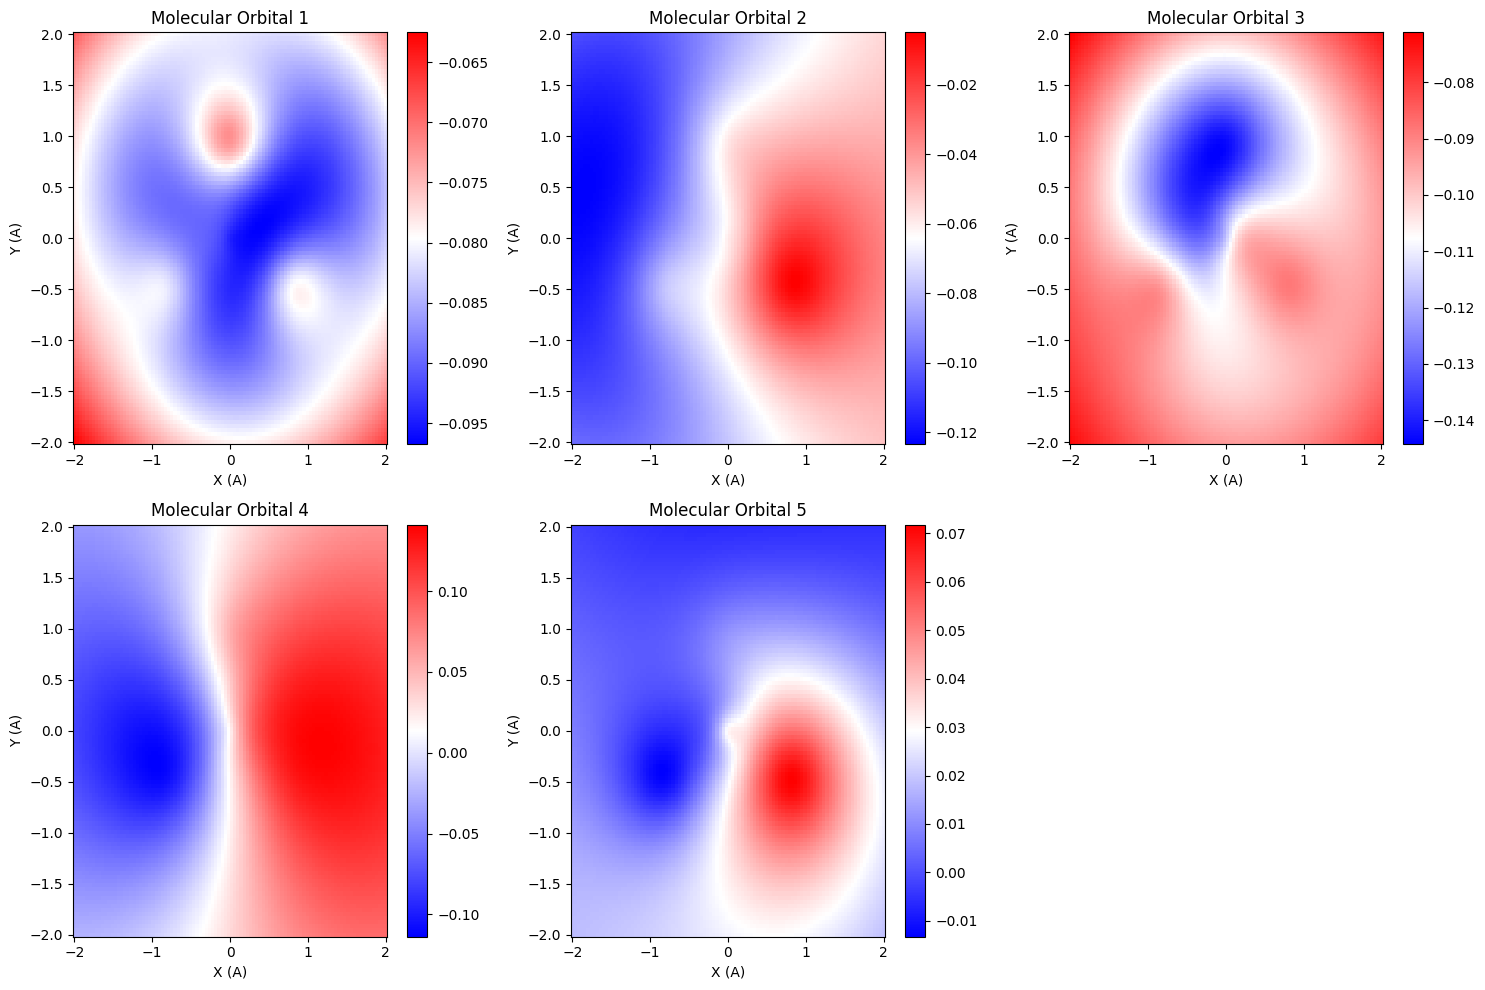

In [9]:
plot_molecular_orbitals_2d(occupied_molecular_orbitals, plane='xy',
                            x_range=(-2, 2), y_range=(-2, 2), n_points=100)


In [10]:
def plot_all_molecular_orbitals_3d(molecular_orbitals,
                                    grid_mesh_X, grid_mesh_Y, grid_mesh_Z,
                                    isosurface_threshold=0.02, alpha=0.1):
    # Scatter-plot occupied MOs in 3-D, showing regions where |psi| > threshold.
    n_mos = len(molecular_orbitals)
    fig, axes = plt.subplots(1, n_mos, subplot_kw={'projection': '3d'},
                             figsize=(5 * n_mos, 6))
    if n_mos == 1:
        axes = [axes]

    for i, mo in enumerate(molecular_orbitals):
        mo_values = np.zeros(grid_mesh_X.shape)
        for j in range(grid_mesh_X.shape[0]):
            for k in range(grid_mesh_X.shape[1]):
                for l in range(grid_mesh_X.shape[2]):
                    pt = [grid_mesh_X[j, k, l],
                          grid_mesh_Y[j, k, l],
                          grid_mesh_Z[j, k, l]]
                    mo_values[j, k, l] = mo.evaluate(pt)

        mask       = np.abs(mo_values) > isosurface_threshold
        color_vals = mo_values[mask]

        axes[i].scatter(grid_mesh_X[mask], grid_mesh_Y[mask], grid_mesh_Z[mask],
                        c=color_vals, cmap='coolwarm', alpha=alpha)
        axes[i].set_title(f'MO {i + 1}')
        axes[i].set_xlabel('X (A)')
        axes[i].set_ylabel('Y (A)')
        axes[i].set_zlabel('Z (A)')

    plt.tight_layout()
    plt.show()





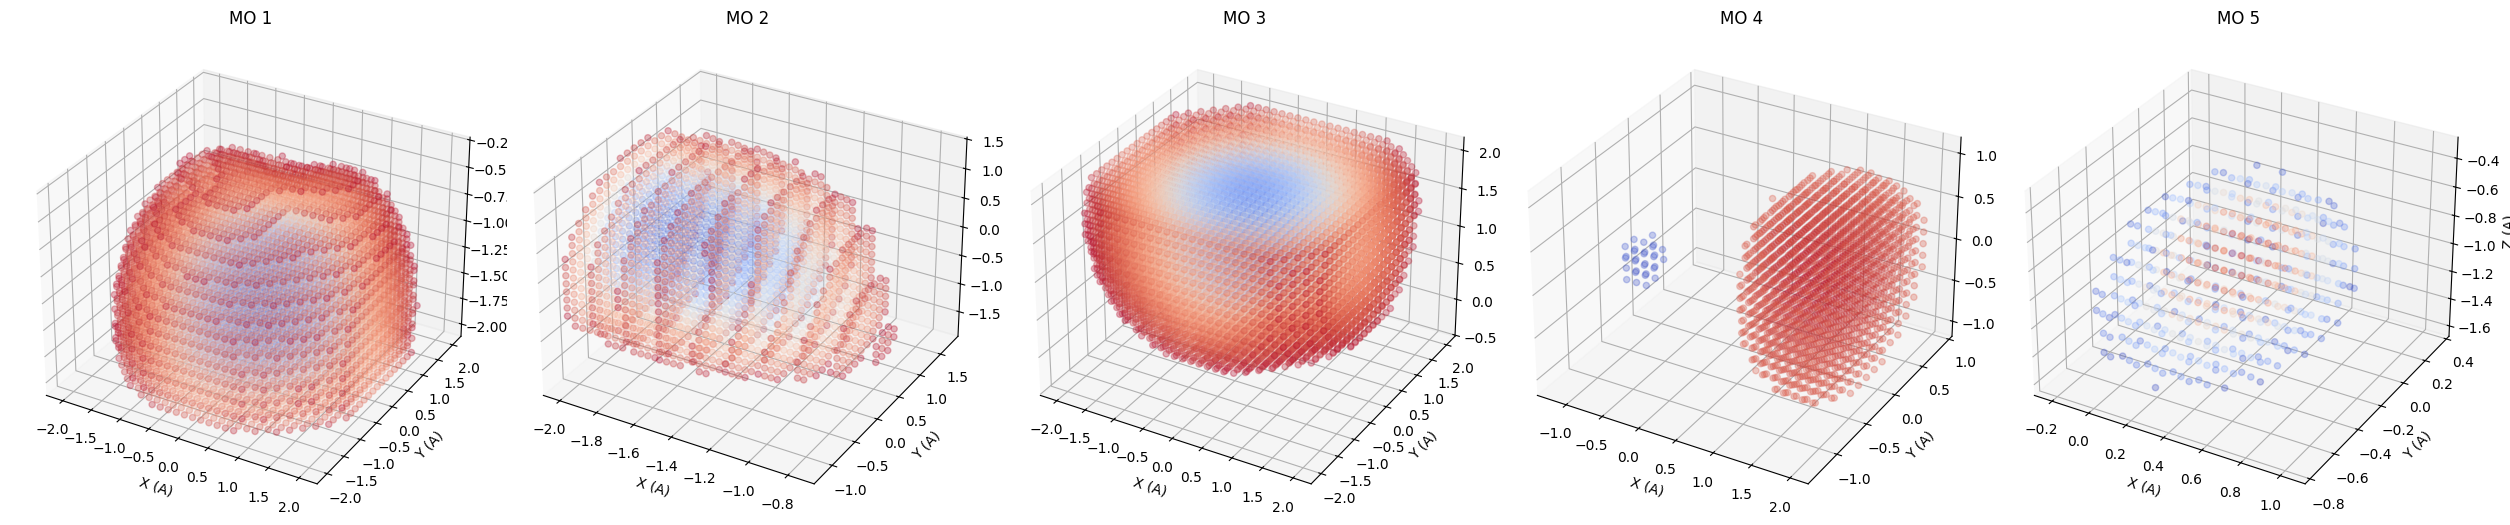

In [11]:
grid_mesh_X, grid_mesh_Y, grid_mesh_Z = create_grid_point_mesh([-2, 2], [-2, 2], [-2, 2], 30)
plot_all_molecular_orbitals_3d(occupied_molecular_orbitals,
                                grid_mesh_X, grid_mesh_Y, grid_mesh_Z,
                                isosurface_threshold=0.11, alpha=0.3)

In [12]:
def plot_basis_functions_with_cutoff(molecular_orbitals, cutoff_value, grid_dim=40):
    # Side-by-side 3-D scatter: with iso-surface cutoff vs full range.
    x = np.linspace(-1, 1, grid_dim)
    y = np.linspace(-1, 1, grid_dim)
    z = np.linspace(-1, 1, grid_dim)
    gX, gY, gZ = np.meshgrid(x, y, z, indexing='ij')

    mo_values = np.zeros(gX.shape)
    for mo in molecular_orbitals:
        for i in range(gX.shape[0]):
            for j in range(gX.shape[1]):
                for k in range(gX.shape[2]):
                    mo_values[i, j, k] += mo.evaluate([gX[i, j, k],
                                                        gY[i, j, k],
                                                        gZ[i, j, k]])

    mask       = np.abs(mo_values) > cutoff_value
    vmin, vmax = mo_values.min(), mo_values.max()

    fig = plt.figure(figsize=(20, 10))

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(gX[mask], gY[mask], gZ[mask],
                c=mo_values[mask], cmap='bwr', alpha=0.1, vmin=vmin, vmax=vmax)
    ax1.set_title(f'Cutoff  |psi| > {cutoff_value}')
    ax1.set_xlabel('X (A)'); ax1.set_ylabel('Y (A)'); ax1.set_zlabel('Z (A)')

    ax2 = fig.add_subplot(122, projection='3d')
    sc2 = ax2.scatter(gX.ravel(), gY.ravel(), gZ.ravel(),
                      c=mo_values.ravel(), cmap='bwr', alpha=0.1, vmin=vmin, vmax=vmax)
    ax2.set_title('Full range')
    ax2.set_xlabel('X (A)'); ax2.set_ylabel('Y (A)'); ax2.set_zlabel('Z (A)')

    plt.colorbar(sc2, ax=[ax1, ax2], orientation='vertical', label='psi value')
    plt.show()





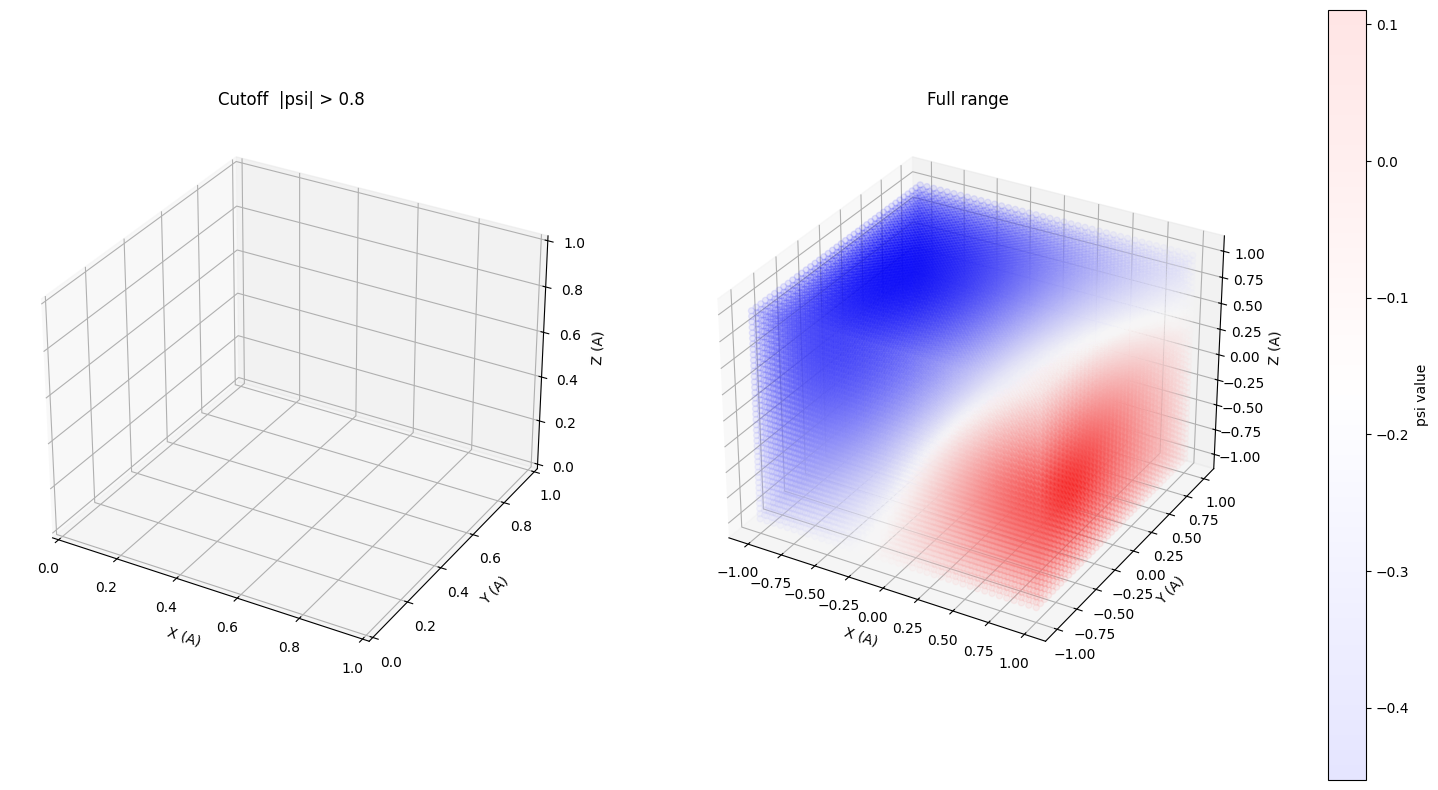

In [13]:
plot_basis_functions_with_cutoff(occupied_molecular_orbitals, cutoff_value=0.8)

## Exchange-Correlation Functionals

The exchange-correlation energy $E_{xc}[\rho]$ encapsulates all quantum many-body effects beyond the classical Hartree repulsion. Its exact form is unknown; practical DFT relies on approximations.

### Local Density Approximation (LDA)

LDA assumes the XC energy density at each point depends only on the local electron density:

$$E_{xc}^{LDA}[\rho] = \int \rho(\mathbf{r})\, \varepsilon_{xc}(\rho(\mathbf{r}))\, d\mathbf{r}$$

The Slater exchange functional (the dominant term) gives:

$$E_x^{LDA}[\rho] = -C_X \int \rho(\mathbf{r})^{4/3} d\mathbf{r}, \quad C_X = \frac{3}{4}\left(\frac{3}{\pi}\right)^{1/3}$$

The corresponding exchange **potential** (functional derivative) is:

$$v_x^{LDA}(\mathbf{r}) = \frac{\delta E_x}{\delta \rho} = -\frac{4}{3} C_X \rho(\mathbf{r})^{1/3}$$

### Generalised Gradient Approximation (GGA)

GGA extends LDA by including a dependence on $|\nabla\rho|$:

$$E_{xc}^{GGA}[\rho] = \int f(\rho, |\nabla\rho|)\, d\mathbf{r}$$

A simplified PBE-like form is implemented for comparison. In this tutorial the SCF uses LDA.


### Step 5: Define exchange-correlation (cell 20)
![Step 5: Define exchange-correlation (cell 20)](./pics/stage5_xc.png)

*Two functionals are coded: LDA exchange (homogeneous-electron-gas formula) and a simplified GGA that adds a gradient term. Both consume rho on the integration grid and return an energy.*


In [14]:
# ---------------------------------------------------------------------------
# Exchange-correlation energy functionals
# ---------------------------------------------------------------------------

def lda_xc_energy_grid(electron_density, grid_points=None):
    # LDA exchange energy:  E_xc^LDA = -C_X * sum(rho^(4/3))
    # C_X = 3/4 * (3/pi)^(1/3)   (homogeneous electron gas)
    # Returns energy in Hartree.
    C_X = 0.75 * (3.0 / np.pi) ** (1.0 / 3.0)
    return -C_X * np.sum(electron_density ** (4.0 / 3.0))


def compute_density_gradient_norm(electron_density):
    # Magnitude of grad(rho) at each grid point via central finite differences.
    grad_components = np.gradient(electron_density)
    return np.sqrt(np.sum(np.square(grad_components), axis=0))


def gga_xc_energy(electron_density, density_gradient_norm):
    # Simplified PBE-like GGA exchange-correlation energy.
    A     = 0.0310907
    alpha = 0.19645
    beta  = 0.046644
    gamma = 0.007296

    rs   = (3.0 / (4.0 * np.pi * electron_density)) ** (1.0 / 3.0)
    s    = density_gradient_norm / (2.0 * (3.0 * np.pi ** 2) ** (1.0 / 3.0)
                                     * electron_density ** (4.0 / 3.0))
    H    = A * (1.0 + alpha * rs) / (1.0 + alpha * rs + beta * rs**2 + gamma * rs**3)
    F_xc = electron_density ** (4.0 / 3.0) * H + beta * s**2 / (1.0 + gamma * s**2)
    return float(np.sum(F_xc))


def compute_xc_energy(electron_density, xc_functional='LDA'):
    # Dispatch to the requested XC functional: 'LDA' or 'GGA'.
    if xc_functional == 'LDA':
        return lda_xc_energy_grid(electron_density)
    elif xc_functional == 'GGA':
        grad_norm = compute_density_gradient_norm(electron_density)
        return gga_xc_energy(electron_density, grad_norm)
    else:
        raise ValueError(f"Unknown XC functional '{xc_functional}'. Use 'LDA' or 'GGA'.")


def external_potential_energy(electron_density, atoms, grid_points):
    # V_ext = -sum_I Z_I * integral rho(r) / |r - R_I| dr
    # (nuclear attraction energy; all quantities in atomic units)
    V_ext = 0.0
    for atom in atoms:
        Z_I = get_atomic_number(atom.element)
        for grid_idx, r_point in enumerate(grid_points):
            dist = np.linalg.norm(r_point - atom.position)
            if dist > 1e-10:
                V_ext += -Z_I * electron_density[grid_idx] / dist
    return V_ext


def thomas_fermi_kinetic_energy(electron_density):
    # Thomas-Fermi kinetic energy: T_TF = C_TF * integral rho^(5/3) dr
    # C_TF = 3/10 * (3 * pi^2)^(2/3)
    C_TF = (3.0 / 10.0) * (3.0 * np.pi ** 2) ** (2.0 / 3.0)
    return C_TF * np.sum(electron_density ** (5.0 / 3.0))


## Kohn-Sham Fock Matrix

In the AO basis, the KS equations become the Roothaan-Hall generalised eigenvalue problem:

$$\mathbf{F}\mathbf{C} = \mathbf{S}\mathbf{C}\boldsymbol{\varepsilon}$$

The KS Fock matrix $F_{\mu\nu}$ is:

$$F_{\mu\nu} = H^{core}_{\mu\nu} + J_{\mu\nu} + V^{xc}_{\mu\nu}$$

where:
- $H^{core}_{\mu\nu} = T_{\mu\nu} + V_{\mu\nu}$ — kinetic + nuclear attraction (density-independent, computed once)
- $J_{\mu\nu} = \int \phi_\mu(\mathbf{r})\, v_H[\rho](\mathbf{r})\, \phi_\nu(\mathbf{r})\, d\mathbf{r}$ — Hartree potential matrix
- $V^{xc}_{\mu\nu} = \int \phi_\mu(\mathbf{r})\, v_{xc}[\rho](\mathbf{r})\, \phi_\nu(\mathbf{r})\, d\mathbf{r}$ — XC potential matrix

Note: This is the **DFT** (KS) Fock matrix. The HF form would replace $J+V^{xc}$ with $2J-K$ using four-centre electron repulsion integrals.


**Compute Overlap Matrix (S):**

The overlap matrix S between basis functions $φ(i)$ and $φ(j)$ is calculated using the following mathematical expression:

$$S_{ij} = ∫ φ_i(r) * φ_j(r) dr$$

Where:
- $S_{ij}$ represents the element of the overlap matrix corresponding to basis functions $φ(i)$ and $φ(j)$.
- $φ_i(r)$ and $φ_j(r)$ are the basis functions evaluated at position r.
- The integral is taken over all space.

**Compute Kinetic Energy Matrix (T):**

The kinetic energy matrix T between basis functions $φ(i)$ and $φ(j)$ is computed using the following mathematical expression:

$$T_{ij} = -∫ φ_i(r) * ∇² * φ_j(r) dr$$

Where:
- $T_{ij}$ represents the element of the kinetic energy matrix corresponding to basis functions $φ(i)$ and $φ(j)$.
-$ φ_i(r) $and $φ_j(r) $are the basis functions evaluated at position r.
- $∇²$ is the Laplacian operator, which calculates the second derivative with respect to position.
- The integral is taken over all space.

**Compute Nuclear Attraction Matrix (V):**

The nuclear attraction matrix V between basis functions $φ(i)$ and $φ(j)$ due to atomic nuclei is determined using the following mathematical expression:

$$V_{ij} = ∫ φ_i(r) * V_nuc(r) * φ_j(r) dr$$

Where:
- $V_{ij}$ represents the element of the nuclear attraction matrix corresponding to basis functions$ φ(i)$ and $φ(j)$.
- $φ_i(r)$ and $φ_j(r)$ are the basis functions evaluated at position r.
- $V_nuc(r)$ is the nuclear attraction potential at position r, which depends on the positions and charges of the atomic nuclei.
- The integral is taken over all space.

These equations describe how the overlap, kinetic energy, and nuclear attraction matrices are computed for a given set of basis functions and atomic positions in a quantum chemistry context.

**electron-electron repulsion (G):** .  (esplicit calculation of exchange term)

The electron-electron repulsion integral between two basis functions, typically denoted as $φ(i)$ and $φ(j)$, is calculated using the following mathematical expression:

$G_{ij} = ∫ ∫ ∫ ∫ (φ_i(r₁) * φ_i(r₂) * φ_j(r₁) * φ_j(r₂)) / |r₁ - r₂| dr₁ dr₂ dr₁ dr₂$

Where:
- $G_{ij}$ is the electron-electron repulsion integral between basis functions $φ(i)$ and $φ(j)$.
- $φ_i(r₁)$ and $φ_j(r₂)$ are the basis functions evaluated at the positions $r₁$ and $r₂$, respectively.
- $|r₁ - r₂|$ represents the Euclidean distance between the two electron positions $r₁$ and $r₂$.
- The integral is taken over all possible values of $r₁$ and $r₂$ in three-dimensional space.


Sure, here are the explanations of both terms along with their respective equations in Markdown format:

**Hartree Energy**

The Hartree energy $ E_{\text{Hartree}} $ arises from the classical electrostatic interaction between electrons due to their own charge density. It is a key component of the total energy in electronic structure calculations. Mathematically, it can be expressed as:

$$
E_{\text{Hartree}} = \frac{1}{2} \int \int \rho(\mathbf{r}_1) \rho(\mathbf{r}_2) \frac{1}{|\mathbf{r}_1 - \mathbf{r}_2|} d\mathbf{r}_1 d\mathbf{r}_2
$$

where $\rho(\mathbf{r}) $ represents the electron density at position $\mathbf{r} $.

**Electron-Electron Repulsion Integral**

The electron-electron repulsion integral $ G_{ij} $ calculates the direct Coulombic repulsion energy between two pairs of electrons described by the basis functions  \phi_i(\mathbf{r})  and  \phi_j(\mathbf{r})). Mathematically, it can be expressed as:

$$
G_{ij} = \int \int \int \int \frac{\phi_i(\mathbf{r}_1) \phi_i(\mathbf{r}_2) \phi_j(\mathbf{r}_1) \phi_j(\mathbf{r}_2)}{|\mathbf{r}_1 - \mathbf{r}_2|} d\mathbf{r}_1 d\mathbf{r}_2 d\mathbf{r}_1 d\mathbf{r}_2
$$

where $ \phi_i(\mathbf{r}) $ and $ \phi_j(\mathbf{r}) $ are the basis functions.

These terms are essential in electronic structure theory, providing insights into the electron-electron interactions within a quantum mechanical framework.

To compute this integral numerically, the function `compute_electron_repulsion_matrix` discretizes the integral using a numerical integration technique. It breaks the integration domain into small volumes, calculates the product of the basis functions at grid points within those volumes, and sums up these products multiplied by the volume elements. This process is repeated for all grid points in the integration domain to approximate the integral value.


### Step 6: Pre-compute basis on grid; build S, T, V (cell 23)
![Step 6: Pre-compute basis on grid; build S, T, V (cell 23)](./pics/stage6_integrals.png)

*The basis functions are evaluated once on the full grid, then S, T, and V are built. These three matrices are density-independent so they are computed before the SCF loop and reused every iteration.*


In [15]:
# ---------------------------------------------------------------------------
# Numerical integral primitives  (atomic units throughout)
# ---------------------------------------------------------------------------

def _grid_volume_element(grid_points):
    # Volume element dV = dx * dy * dz for a uniform 3-D grid.
    spacings = []
    for k in range(3):
        unique_vals = np.unique(grid_points[:, k])
        spacings.append(unique_vals[1] - unique_vals[0] if len(unique_vals) > 1 else 1.0)
    return float(np.prod(spacings))


def numerical_laplacian(basis_function, point, delta=1e-4):
    # Finite-difference Laplacian at a single point.
    # Laplacian_phi(r) ~= sum_k [phi(r+delta*ek) - 2*phi(r) + phi(r-delta*ek)] / delta^2
    point     = np.asarray(point, dtype=float)
    laplacian = 0.0
    f0        = basis_function.evaluate(point)
    for k in range(3):
        pt_fwd       = point.copy(); pt_fwd[k]  += delta
        pt_bwd       = point.copy(); pt_bwd[k]  -= delta
        laplacian   += (basis_function.evaluate(pt_fwd)
                        - 2.0 * f0
                        + basis_function.evaluate(pt_bwd)) / delta ** 2
    return laplacian


# ---------------------------------------------------------------------------
# Pre-compute basis function values on the entire grid once.
# Calling this once and passing the result into all integral functions avoids
# redundant evaluations and makes the code much faster.
# ---------------------------------------------------------------------------

def precompute_basis_values(basis_functions, grid_points):
    # Returns ndarray of shape (n_basis, n_grid):  bf_values[mu, p] = phi_mu(r_p)
    return np.array([[bf.evaluate(pt) for pt in grid_points]
                     for bf in basis_functions])


# ---------------------------------------------------------------------------
# One-electron integrals
# ---------------------------------------------------------------------------

def kinetic_matrix(basis_functions, grid_points, delta=1e-4):
    # Kinetic energy matrix:  T_{ij} = -1/2 * integral phi_i(r) * Laplacian[phi_j(r)] dr
    # Uses numerical Laplacian (central finite differences) for phi_j.
    # Result is symmetrised: T = 1/2 (T + T^T) to correct for numerical asymmetry.
    n_basis = len(basis_functions)
    dV      = _grid_volume_element(grid_points)
    T       = np.zeros((n_basis, n_basis))

    # Pre-evaluate phi_i values (do NOT pre-evaluate Laplacians; too much memory for large grids)
    for j in range(n_basis):
        # Compute Laplacian of phi_j at every grid point
        lap_j = np.array([numerical_laplacian(basis_functions[j], pt, delta)
                          for pt in grid_points])   # shape (n_grid,)
        for i in range(n_basis):
            phi_i = np.array([basis_functions[i].evaluate(pt) for pt in grid_points])
            T[i, j] = -0.5 * np.dot(phi_i, lap_j) * dV

    return 0.5 * (T + T.T)   # symmetrise


def nuclear_attraction_matrix(basis_functions, atoms, grid_points, bf_values=None):
    # Nuclear-attraction matrix:
    #   V_{ij} = integral phi_i(r) * V_nuc(r) * phi_j(r) dr
    #   V_nuc(r) = -sum_I Z_I / |r - R_I|
    n_basis = len(basis_functions)
    n_grid  = len(grid_points)
    dV      = _grid_volume_element(grid_points)

    if bf_values is None:
        bf_values = precompute_basis_values(basis_functions, grid_points)

    # Build nuclear potential on grid: shape (n_grid,)
    v_nuc = np.zeros(n_grid)
    for atom in atoms:
        diffs = grid_points - atom.position[np.newaxis, :]      # (n_grid, 3)
        dists = np.linalg.norm(diffs, axis=1)                   # (n_grid,)
        mask  = dists > 1e-10
        v_nuc[mask] += -get_atomic_number(atom.element) / dists[mask]

    # V_{ij} = sum_p phi_i(r_p) * v_nuc(r_p) * phi_j(r_p) * dV
    # Vectorised via einsum
    return np.einsum('ip,p,jp->ij', bf_values, v_nuc, bf_values) * dV


def overlap_matrix(basis_functions, grid_points, bf_values=None):
    # Overlap matrix:  S_{ij} = integral phi_i(r) * phi_j(r) dr
    dV = _grid_volume_element(grid_points)
    if bf_values is None:
        bf_values = precompute_basis_values(basis_functions, grid_points)
    return bf_values @ bf_values.T * dV


# Alias used by SCF loop
def compute_overlap_matrix(basis_functions, grid_points):
    return overlap_matrix(basis_functions, grid_points)


# ---------------------------------------------------------------------------
# Electron density and two-electron contributions
# ---------------------------------------------------------------------------

def compute_electron_density_on_grid(density_matrix, bf_values):
    # rho(r_p) = sum_{mu,nu} P_{mu,nu} * phi_mu(r_p) * phi_nu(r_p)
    # Parameters:
    #   density_matrix : ndarray (n_basis, n_basis)
    #   bf_values      : ndarray (n_basis, n_grid)
    # Returns ndarray (n_grid,)
    return np.einsum('mn,mp,np->p', density_matrix, bf_values, bf_values)


def compute_hartree_potential_on_grid(electron_density, grid_points):
    # Hartree potential:  v_H(r_i) = sum_{j} rho(r_j) / |r_i - r_j| * dV
    # Uses pairwise distance matrix; diagonal regularised by the grid cell size
    # (Wigner-Seitz-like self-interaction cutoff).
    dV    = _grid_volume_element(grid_points)
    r_cut = dV ** (1.0 / 3.0)   # ~cell edge length (a.u.)

    # Pairwise distances: shape (n_grid, n_grid)
    diff       = grid_points[:, np.newaxis, :] - grid_points[np.newaxis, :, :]
    dist       = np.linalg.norm(diff, axis=2)
    np.fill_diagonal(dist, r_cut)   # regularise self-interaction

    # v_H[i] = sum_j rho[j] / dist[i,j] * dV
    v_H = (dist ** -1) @ electron_density * dV
    return v_H


def hartree_matrix_contribution(v_hartree, bf_values, grid_points):
    # Hartree contribution to the Fock matrix:
    #   J_{ij} = integral phi_i(r) * v_H(r) * phi_j(r) dr
    dV = _grid_volume_element(grid_points)
    return np.einsum('ip,p,jp->ij', bf_values, v_hartree, bf_values) * dV


def lda_xc_potential_on_grid(electron_density):
    # LDA Slater exchange potential:
    #   v_xc(r) = dE_xc/drho = -(4/3) * C_X * rho(r)^(1/3)
    # where C_X = 3/4 * (3/pi)^(1/3)  (Dirac exchange constant).
    C_X = 0.75 * (3.0 / np.pi) ** (1.0 / 3.0)
    return -(4.0 / 3.0) * C_X * np.abs(electron_density) ** (1.0 / 3.0)


def xc_matrix_contribution(v_xc, bf_values, grid_points):
    # XC contribution to the Fock matrix:
    #   XC_{ij} = integral phi_i(r) * v_xc(r) * phi_j(r) dr
    dV = _grid_volume_element(grid_points)
    return np.einsum('ip,p,jp->ij', bf_values, v_xc, bf_values) * dV


def lda_xc_energy(electron_density, grid_points):
    # LDA Slater exchange energy:
    #   E_xc = -C_X * integral rho(r)^(4/3) dr
    # This is the ENERGY (not the potential), used only in total energy evaluation.
    C_X = 0.75 * (3.0 / np.pi) ** (1.0 / 3.0)
    dV  = _grid_volume_element(grid_points)
    return -C_X * np.sum(np.abs(electron_density) ** (4.0 / 3.0)) * dV


def hartree_energy(electron_density, v_hartree, grid_points):
    # E_H = 1/2 * integral rho(r) * v_H(r) dr
    dV = _grid_volume_element(grid_points)
    return 0.5 * np.dot(electron_density, v_hartree) * dV


When using atomic orbitals as the basis set in quantum chemistry, particularly in the context of Density Functional Theory (DFT) and the Kohn-Sham (KS) formalism, the calculation of the density matrix is somewhat different from that in a plane wave basis. Here's how you can calculate the density matrix in this context:

### 1. Expand KS Orbitals in Atomic Orbital Basis
First, the Kohn-Sham orbitals \(\psi_i(\mathbf{r})\) are expanded in terms of a set of atomic orbitals (basis functions) \(\phi_\mu(\mathbf{r})\). The expansion can be written as:


$$ \psi_i(\mathbf{r}) = \sum_\mu C_{\mu i} \phi_\mu(\mathbf{r}) $$

where $C_{\mu i}$ are the expansion coefficients for the \(i\)-th KS orbital in terms of the basis function indexed by $\mu$.

### 2. Define the Density Matrix
In terms of these coefficients, the density matrix \(\gamma_{\mu\nu}\) in the atomic orbital basis is defined as:

$$
\gamma_{\mu\nu} = \sum_i f_i C_{\mu i} C_{\nu i}^*
$$

Here, \(f_i\) are the occupation numbers of the KS orbitals, which depend on the temperature and the electronic configuration (for T=0 K, it's 1 for occupied orbitals and 0 for unoccupied ones). The indices \(\mu\) and \(\nu\) run over the atomic orbitals in the basis set, and \(i\) runs over the KS orbitals.

### 3. Calculate the Electron Density
The electron density \(\rho(\mathbf{r})\) at any point in space can be obtained from the density matrix:

$$
\rho(\mathbf{r}) = \sum_{\mu\nu} \gamma_{\mu\nu} \phi_\mu(\mathbf{r}) \phi_\nu^*(\mathbf{r})
$$

### Practical Aspects:
- **Self-Consistent Field (SCF) Procedure**: In practical DFT calculations, this process is part of the SCF procedure. The electron density $\rho(\mathbf{r})$ is used to construct the effective potential $V_{\text{eff}}(\mathbf{r})$, which in turn is used to solve the KS equations and update the coefficients $C_{\mu i}$. This cycle is repeated until self-consistency is achieved.
- **Computational Considerations**: The size of the density matrix $\gamma_{\mu\nu}$ is determined by the number of atomic orbitals in the basis set, which can be quite large for complex systems. Efficient algorithms and approximations are often necessary for practical computations.
- **Basis Set Dependence**: The choice of basis set (like STO-3G, 6-31G, cc-pVDZ, etc.) can significantly affect the results. The quality and type of the basis set should be appropriate for the system and properties being studied.

In summary, when using atomic orbitals as a basis set, the density matrix is constructed from the expansion coefficients of the KS orbitals in that basis. This density matrix is then used to calculate the electron density, a key quantity in DFT calculations.


### Step 7: Aufbau initial density matrix (cells 25 - 26)
![Step 7: Aufbau initial density matrix (cells 25 - 26)](./pics/stage7_P0.png)

*Build P^(0) by placing 2 on the first n_occ diagonal entries (Aufbau principle, doubly-occupied) and 0 elsewhere. Trace = N_el by construction. Crude, but the SCF will refine it.*


In [16]:
def build_initial_density_matrix_from_aufbau(basis_functions, num_electrons):
    # Build a diagonal density matrix assuming Aufbau (double) occupancy.
    # Each of the n_occ lowest-index basis functions gets P_ii = 2.
    # This is a rough initial guess; the SCF will refine it.
    n_basis        = len(basis_functions)
    density_matrix = np.zeros((n_basis, n_basis))
    n_occ          = min(num_electrons // 2, n_basis)
    for i in range(n_occ):
        density_matrix[i, i] = 2.0   # two electrons (spin up + spin down)
    return density_matrix


In [17]:
# Display the initial density matrix (Aufbau diagonal guess from AO occupancy)
initial_density_matrix = build_initial_density_matrix_from_aufbau(
    atomic_orbitals, num_electrons)
print("Initial density matrix (Aufbau diagonal guess):\n", initial_density_matrix)


Initial density matrix (Aufbau diagonal guess):
 [[2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


## Density Matrix and SCF Iteration

The one-particle **density matrix** in the AO basis is:

$$P_{\mu\nu} = 2\sum_{i}^{occ} C_{\mu i} C_{\nu i}$$

where the factor of 2 accounts for double spin occupancy (closed-shell). It satisfies:
- $\text{Tr}(\mathbf{P}\mathbf{S}) = N_{el}$ — correct electron count
- $\mathbf{P}\mathbf{S}\mathbf{P} = 2\mathbf{P}$ — idempotency (pure-state density matrix)

The electron density at any real-space point follows directly:

$$\rho(\mathbf{r}) = \sum_{\mu\nu} P_{\mu\nu}\, \phi_\mu(\mathbf{r})\, \phi_\nu(\mathbf{r})$$

The **SCF cycle** iterates:
1. Build $\mathbf{F}[\rho]$ from the current density
2. Solve $\mathbf{F}\mathbf{C} = \mathbf{S}\mathbf{C}\boldsymbol{\varepsilon}$
3. Update $\mathbf{P}$ from occupied columns of $\mathbf{C}$
4. Mix: $\mathbf{P} \leftarrow (1-\alpha)\mathbf{P}_{old} + \alpha\mathbf{P}_{new}$
5. Check $|E_{new} - E_{old}| < \epsilon$


### Step 8: Wire up F and P (cells 28 - 29)
![Step 8: Wire up F and P (cells 28 - 29)](./pics/stage8_F_and_P.png)

*compute_fock_matrix assembles F = T + V + J[rho] + V_xc[rho]; the first two are reused from step 6, the last two are rebuilt from the current density each iteration. compute_density_matrix turns the new C back into a new P; mix_density_matrices linearly damps the update to prevent SCF oscillation.*


In [18]:
def compute_fock_matrix(basis_functions, density_matrix, atoms, grid_points,
                        T_matrix=None, V_matrix=None, bf_values=None):
    # Build the Kohn-Sham Fock matrix:
    #   F = H_core + J + V_xc
    #   H_core_{ij} = T_{ij} + V_{ij}   (kinetic + nuclear attraction)
    #   J_{ij}      = integral phi_i(r) v_H[rho](r) phi_j(r) dr   (Hartree)
    #   V_xc_{ij}   = integral phi_i(r) v_xc[rho](r) phi_j(r) dr  (LDA XC)
    #
    # T and V are density-independent and can be pre-computed once and passed in
    # to avoid rebuilding them every SCF iteration.
    #
    # All quantities in atomic units.

    if bf_values is None:
        bf_values = precompute_basis_values(basis_functions, grid_points)

    # One-electron part (constant across SCF iterations if passed in)
    if T_matrix is None:
        T_matrix = kinetic_matrix(basis_functions, grid_points)
    if V_matrix is None:
        V_matrix = nuclear_attraction_matrix(basis_functions, atoms, grid_points, bf_values)

    H_core = T_matrix + V_matrix

    # Electron density on grid from current density matrix
    electron_density = compute_electron_density_on_grid(density_matrix, bf_values)

    # Hartree potential and matrix contribution
    v_hartree  = compute_hartree_potential_on_grid(electron_density, grid_points)
    J_matrix   = hartree_matrix_contribution(v_hartree, bf_values, grid_points)

    # LDA exchange-correlation potential and matrix contribution
    v_xc       = lda_xc_potential_on_grid(electron_density)
    XC_matrix  = xc_matrix_contribution(v_xc, bf_values, grid_points)

    fock_matrix = H_core + J_matrix + XC_matrix
    return fock_matrix


def solve_roothaan_hall(fock_matrix, overlap_matrix,
                        linear_dependence_threshold=1e-7):
    # Solve the generalised eigenvalue problem  F C = S C epsilon
    # using canonical orthogonalisation with threshold truncation.
    #
    # Steps:
    #   1. Diagonalise S = U Lambda U^T
    #   2. Discard eigenvectors with Lambda_k < threshold  (near-linear dependence)
    #   3. Build X = U'_keep * Lambda_keep^{-1/2}
    #   4. Solve standard eigenvalue problem in reduced space: F' = X^T F X
    #   5. Back-transform: C = X C'
    #
    # The returned MO coefficients C satisfy C^T S C = I (up to truncation),
    # so the density matrix P = 2 C_occ C_occ^T satisfies Tr(P S) = N_electrons.

    eigvals_S, eigvecs_S  = np.linalg.eigh(overlap_matrix)

    keep      = eigvals_S > linear_dependence_threshold
    n_kept    = int(np.sum(keep))
    lam_keep  = eigvals_S[keep]
    U_keep    = eigvecs_S[:, keep]                    # (n_basis, n_kept)

    X         = U_keep / np.sqrt(lam_keep)            # (n_basis, n_kept)  broadcast

    F_ortho   = X.T @ fock_matrix @ X                 # (n_kept, n_kept)
    orbital_energies_kept, C_ortho = np.linalg.eigh(F_ortho)

    mo_coefficients  = X @ C_ortho                    # (n_basis, n_kept)

    # Embed into full (n_basis, n_basis) arrays; trailing columns are zero / NaN
    n_basis   = fock_matrix.shape[0]
    orb_en    = np.full(n_basis, np.nan)
    C_full    = np.zeros((n_basis, n_basis))
    orb_en[:n_kept]       = orbital_energies_kept
    C_full[:, :n_kept]    = mo_coefficients

    return orb_en, C_full


In [19]:
def compute_density_matrix(mo_coefficients, num_electrons):
    # One-particle density matrix (closed-shell):
    #   P_{mu,nu} = 2 * sum_{i=1}^{n_occ} C_{mu,i} * C_{nu,i}
    #
    # The MO coefficient columns from solve_roothaan_hall satisfy C^T S C = I,
    # so Tr(P S) = 2 * n_occ = N_electrons by construction.
    #
    # Only the first n_occ columns are used; trailing columns (including any
    # NaN from discarded near-linear-dependent vectors) are safely ignored.
    n_occ = num_electrons // 2
    C_occ = np.nan_to_num(mo_coefficients[:, :n_occ], nan=0.0)
    return 2.0 * (C_occ @ C_occ.T)


def mix_density_matrices(old_density_matrix, new_density_matrix, mixing_param=0.30):
    # Linear mixing for SCF damping:  P_out = (1 - alpha) P_old + alpha P_new
    # Smaller alpha gives more conservative (oscillation-damped) updates.
    return (1.0 - mixing_param) * old_density_matrix + mixing_param * new_density_matrix


## <center>**SCF Algorithm** </center>                



### Step 9: Wire up F and P (cells 28 - 29)
![Step 9 scf cycle](./pics/KS_EQ.png)

In [20]:
def compute_total_energy(density_matrix, T_matrix, V_matrix, electron_density,
                         v_hartree, grid_points, atoms):
    # Total DFT energy (Kohn-Sham):
    #
    #   E_tot = Tr[P H_core]  +  E_H  +  E_xc  +  E_nn
    #
    #   Tr[P H_core] = sum_{mu,nu} P_{mu,nu} (T_{mu,nu} + V_{mu,nu})  one-electron
    #   E_H  = 1/2 * integral rho(r) v_H(r) dr                         Hartree
    #   E_xc = -C_X * integral rho^(4/3) dr                            LDA exchange
    #   E_nn = sum_{I<J} Z_I Z_J / R_{IJ}                              nuclear repulsion
    #
    # Double-counting is avoided by using energy components directly,
    # rather than E = 1/2 Tr[P(H_core + F)] which overcounts E_H and E_xc.

    H_core         = T_matrix + V_matrix
    E_one_electron = np.sum(density_matrix * H_core)
    E_H            = hartree_energy(electron_density, v_hartree, grid_points)
    E_xc           = lda_xc_energy(electron_density, grid_points)

    E_nn = 0.0
    for i, atom_i in enumerate(atoms):
        for j, atom_j in enumerate(atoms):
            if i < j:
                Z_i  = get_atomic_number(atom_i.element)
                Z_j  = get_atomic_number(atom_j.element)
                R_ij = np.linalg.norm(atom_i.position - atom_j.position)
                E_nn += Z_i * Z_j / R_ij

    return E_one_electron + E_H + E_xc + E_nn


def scf_cycle(basis_functions, atoms, grid_points, initial_mo_coefficients,
              num_electrons, max_iter=30, energy_threshold=1e-7,
              density_mixing=0.30):
    # Kohn-Sham self-consistent field loop.
    #
    # Pre-computes the density-independent one-electron matrices T, V, S once,
    # then iterates:
    #   1.  rho(r) = Sigma_{mu,nu} P_{mu,nu} phi_mu(r) phi_nu(r)
    #   2.  v_H(r) = integral rho(r') / |r - r'| dr'   (Hartree potential)
    #   3.  v_xc(r) = -4/3 C_X rho^(1/3)               (LDA Slater exchange)
    #   4.  F = H_core + J[rho] + V_xc[rho]
    #   5.  Solve F C = S C epsilon  (canonical orthogonalisation)
    #   6.  P' = 2 C_occ C_occ^T
    #   7.  Mix: P <- (1-alpha) P + alpha P'
    #   8.  Evaluate E_tot[P']
    #   9.  Check |E_new - E_old| < energy_threshold
    #
    # Convergence criterion is energy change |DeltaE| rather than Frobenius
    # norm of DeltaP, because in a non-orthogonal AO basis Tr(P) >> N_el and
    # ||P||_F is dominated by the basis metric, not the electron density.
    # Energy convergence is the physically meaningful criterion used in
    # production DFT codes (VASP, Quantum ESPRESSO, etc.).
    #
    # Parameters
    #   basis_functions         : list of GaussianBasisFunction
    #   atoms                   : list of Atom
    #   grid_points             : ndarray (n_grid, 3)
    #   initial_mo_coefficients : ndarray (n_basis, n_basis)
    #   num_electrons           : int
    #   max_iter                : int
    #   energy_threshold        : float  |E_new - E_old| convergence criterion (Ha)
    #   density_mixing          : float  alpha in (0, 1]
    #
    # Returns
    #   total_energy   : float
    #   density_matrix : ndarray (n_basis, n_basis)  final (mixed) density matrix
    #   fock_matrix    : ndarray (n_basis, n_basis)  final Fock matrix
    #   converged      : bool

    print("Pre-computing one-electron matrices T, V, S  (constant across SCF)...")
    bf_values  = precompute_basis_values(basis_functions, grid_points)
    T_matrix   = kinetic_matrix(basis_functions, grid_points)
    V_matrix   = nuclear_attraction_matrix(basis_functions, atoms, grid_points, bf_values)
    S_matrix   = overlap_matrix(basis_functions, grid_points, bf_values)
    print(f"  T[0,0] = {T_matrix[0,0]:.4f}  "
          f"V[0,0] = {V_matrix[0,0]:.4f}  "
          f"S[0,0] = {S_matrix[0,0]:.4f}")

    # Build initial density matrix.
    # The EHT seed uses orthonormal eigenvectors (Huckel), so P0 has Tr(P)=N
    # but Tr(P S) << N in the AO metric.  After the first Roothaan-Hall step
    # the coefficients satisfy C^T S C = I, giving Tr(P S) = N_el correctly.
    density_matrix = compute_density_matrix(initial_mo_coefficients, num_electrons)

    total_energy = np.nan
    prev_energy  = np.nan
    fock_matrix  = np.zeros_like(T_matrix)
    converged    = False

    for iteration in range(1, max_iter + 1):

        # Build Fock matrix using current density matrix
        fock_matrix = compute_fock_matrix(
                          basis_functions, density_matrix, atoms, grid_points,
                          T_matrix=T_matrix, V_matrix=V_matrix, bf_values=bf_values)

        # Diagonalise: F C = S C epsilon
        orbital_energies, mo_coeff_matrix = solve_roothaan_hall(fock_matrix, S_matrix)

        # New density matrix from occupied MOs
        new_density_matrix = compute_density_matrix(mo_coeff_matrix, num_electrons)

        # Evaluate total energy at the new (pure Roothaan-Hall) density matrix
        electron_density = compute_electron_density_on_grid(new_density_matrix, bf_values)
        v_hartree        = compute_hartree_potential_on_grid(electron_density, grid_points)
        total_energy     = compute_total_energy(
                               new_density_matrix, T_matrix, V_matrix,
                               electron_density, v_hartree, grid_points, atoms)

        # Convergence: energy change between iterations
        delta_E      = abs(total_energy - prev_energy)
        tr_PS        = np.trace(new_density_matrix @ S_matrix)

        print(f"  Iter {iteration:2d}  "
              f"E = {total_energy:14.6f} Ha  "
              f"|dE| = {delta_E:.2e}  "
              f"Tr(P'S) = {tr_PS:.3f}")

        # Mix density matrix for stability (prevents oscillations in the first few steps)
        density_matrix = mix_density_matrices(density_matrix, new_density_matrix, density_mixing)
        prev_energy    = total_energy

        if not np.isnan(delta_E) and delta_E < energy_threshold:
            print(f"  Converged in {iteration} iteration(s)  "
                  f"(|dE| = {delta_E:.2e} < {energy_threshold:.0e} Ha).")
            converged = True
            break

    if not converged:
        print(f"  Warning: SCF did not converge within {max_iter} iterations.")

    # Return the last Roothaan-Hall density matrix (satisfies Tr(P S)=N),
    # not the mixed one (which is only used for iteration stability).
    return total_energy, new_density_matrix, fock_matrix, converged


In [21]:
# ---------------------------------------------------------------------------
# Run the SCF
# ---------------------------------------------------------------------------

# Coarse integration grid (increase n_points for better accuracy).
# 10 pts/axis = 1000 grid points; manageable runtime for a tutorial (~1 min).
# For more quantitative results use 15-20 pts/axis.
grid_points = create_grid_points((-2, 2), (-2, 2), (-2, 2), n_points=10)

print(f"Grid points    : {len(grid_points)}")
print(f"Basis functions: {len(atomic_orbitals)}")
print(f"Electrons      : {num_electrons}")
print("Starting SCF...\n")

total_energy, converged_density, final_fock, scf_converged = scf_cycle(
    basis_functions         = atomic_orbitals,
    atoms                   = atoms,
    grid_points             = grid_points,
    initial_mo_coefficients = mo_coeff_matrix,
    num_electrons           = num_electrons,
    max_iter                = 20,
    energy_threshold        = 1e-7,   # convergence on |dE| in Hartree
    density_mixing          = 0.30,
)

print(f"\nFinal Total Energy : {total_energy:.6f}  Hartree")
print(f"SCF converged      : {scf_converged}")


Grid points    : 1000
Basis functions: 15
Electrons      : 10
Starting SCF...

Pre-computing one-electron matrices T, V, S  (constant across SCF)...
  T[0,0] = -0.0014  V[0,0] = -0.0085  S[0,0] = 0.0004
  Iter  1  E =     -63.417283 Ha  |dE| = nan  Tr(P'S) = 10.000
  Iter  2  E =     -64.143717 Ha  |dE| = 7.26e-01  Tr(P'S) = 10.000
  Iter  3  E =     -64.762886 Ha  |dE| = 6.19e-01  Tr(P'S) = 10.000
  Iter  4  E =     -65.199158 Ha  |dE| = 4.36e-01  Tr(P'S) = 10.000
  Iter  5  E =     -65.459450 Ha  |dE| = 2.60e-01  Tr(P'S) = 10.000
  Iter  6  E =     -65.576929 Ha  |dE| = 1.17e-01  Tr(P'S) = 10.000
  Iter  7  E =     -65.617164 Ha  |dE| = 4.02e-02  Tr(P'S) = 10.000
  Iter  8  E =     -65.628676 Ha  |dE| = 1.15e-02  Tr(P'S) = 10.000
  Iter  9  E =     -65.631731 Ha  |dE| = 3.06e-03  Tr(P'S) = 10.000
  Iter 10  E =     -65.632549 Ha  |dE| = 8.18e-04  Tr(P'S) = 10.000
  Iter 11  E =     -65.632782 Ha  |dE| = 2.34e-04  Tr(P'S) = 10.000
  Iter 12  E =     -65.632856 Ha  |dE| = 7.34e-05  Tr(

## Post-SCF Analysis: Orbital Energies, HOMO, LUMO, Charge Density

Once the SCF has converged, the final Fock matrix $\mathbf{F}$ is re-diagonalised to extract the KS orbital energies and converged MO coefficients. The HOMO (highest occupied MO) and LUMO (lowest unoccupied MO) are identified and plotted alongside the converged charge density $\rho(\mathbf{r}) = \sum_{\mu\nu}P_{\mu\nu}\phi_\mu(\mathbf{r})\phi_\nu(\mathbf{r})$.

In [22]:
# ---------------------------------------------------------------------------
# Post-SCF analysis: extract converged orbital energies and MO coefficients
# ---------------------------------------------------------------------------
# Re-diagonalise the final Fock matrix with the converged overlap matrix
# to obtain the orbital energy spectrum and KS eigenvectors.

# Rebuild the pre-computed matrices on the SCF grid
_bfv_conv  = precompute_basis_values(atomic_orbitals, grid_points)
_S_conv    = overlap_matrix(atomic_orbitals, grid_points, _bfv_conv)

# Solve F_final C = S C epsilon
orbital_energies_Ha, converged_mo_coeffs = solve_roothaan_hall(final_fock, _S_conv)

# Orbital energies in eV (1 Ha = 27.2114 eV) — filter out NaN from discarded vectors
valid_mask   = ~np.isnan(orbital_energies_Ha)
valid_eV     = orbital_energies_Ha[valid_mask] * 27.2114
n_occ        = num_electrons // 2
homo_idx     = n_occ - 1
lumo_idx     = n_occ          # first virtual

# Converged electron density on the SCF grid
converged_rho = compute_electron_density_on_grid(converged_density, _bfv_conv)

print("=" * 55)
print(f"  Converged KS orbital energies")
print("=" * 55)
for i, (e_Ha, e_eV) in enumerate(zip(orbital_energies_Ha[valid_mask], valid_eV)):
    tag = ""
    if i == homo_idx: tag = "  <-- HOMO"
    if i == lumo_idx: tag = "  <-- LUMO"
    label = "occ" if i < n_occ else "virt"
    print(f"  MO {i+1:2d}  [{label}]  {e_Ha:9.4f} Ha  {e_eV:9.3f} eV{tag}")

homo_eV = orbital_energies_Ha[homo_idx] * 27.2114
lumo_eV = orbital_energies_Ha[lumo_idx] * 27.2114
gap_eV  = lumo_eV - homo_eV
print("-" * 55)
print(f"  HOMO energy : {homo_eV:.3f} eV")
print(f"  LUMO energy : {lumo_eV:.3f} eV")
print(f"  HOMO-LUMO gap : {gap_eV:.3f} eV")
print(f"\n  Tr(P_conv @ S) = {np.trace(converged_density @ _S_conv):.4f}  (= N_el = {num_electrons})")


  Converged KS orbital energies
  MO  1  [occ]   -22.5145 Ha   -612.651 eV
  MO  2  [occ]    -1.3508 Ha    -36.758 eV
  MO  3  [occ]    -0.8972 Ha    -24.414 eV
  MO  4  [occ]    -0.4281 Ha    -11.649 eV
  MO  5  [occ]    -0.4067 Ha    -11.066 eV  <-- HOMO
  MO  6  [virt]    -0.0799 Ha     -2.174 eV  <-- LUMO
  MO  7  [virt]     0.0686 Ha      1.866 eV
  MO  8  [virt]     0.2997 Ha      8.155 eV
  MO  9  [virt]     0.3663 Ha      9.967 eV
  MO 10  [virt]     0.4977 Ha     13.544 eV
  MO 11  [virt]     1.5022 Ha     40.877 eV
  MO 12  [virt]     1.8812 Ha     51.190 eV
  MO 13  [virt]     4.3099 Ha    117.279 eV
-------------------------------------------------------
  HOMO energy : -11.066 eV
  LUMO energy : -2.174 eV
  HOMO-LUMO gap : 8.892 eV

  Tr(P_conv @ S) = 10.0000  (= N_el = 10)


Plotting orbital energy diagram...


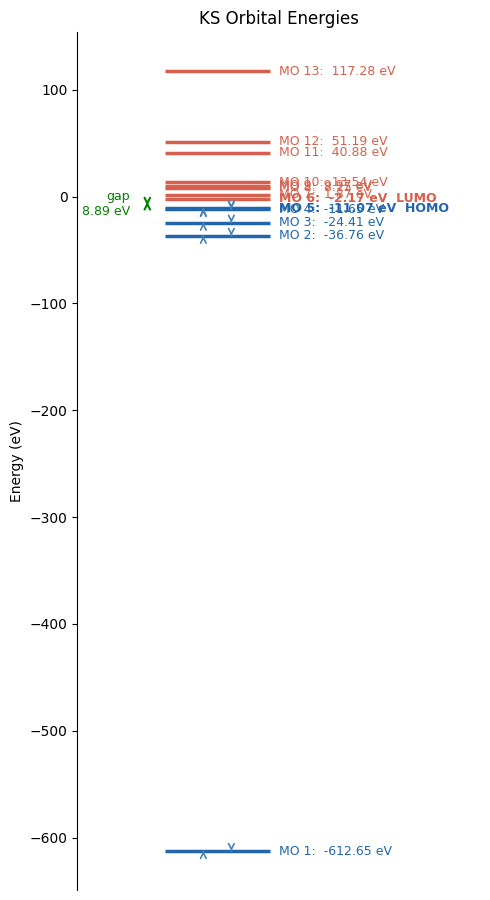

Plotting HOMO, LUMO and charge density (xz plane)...


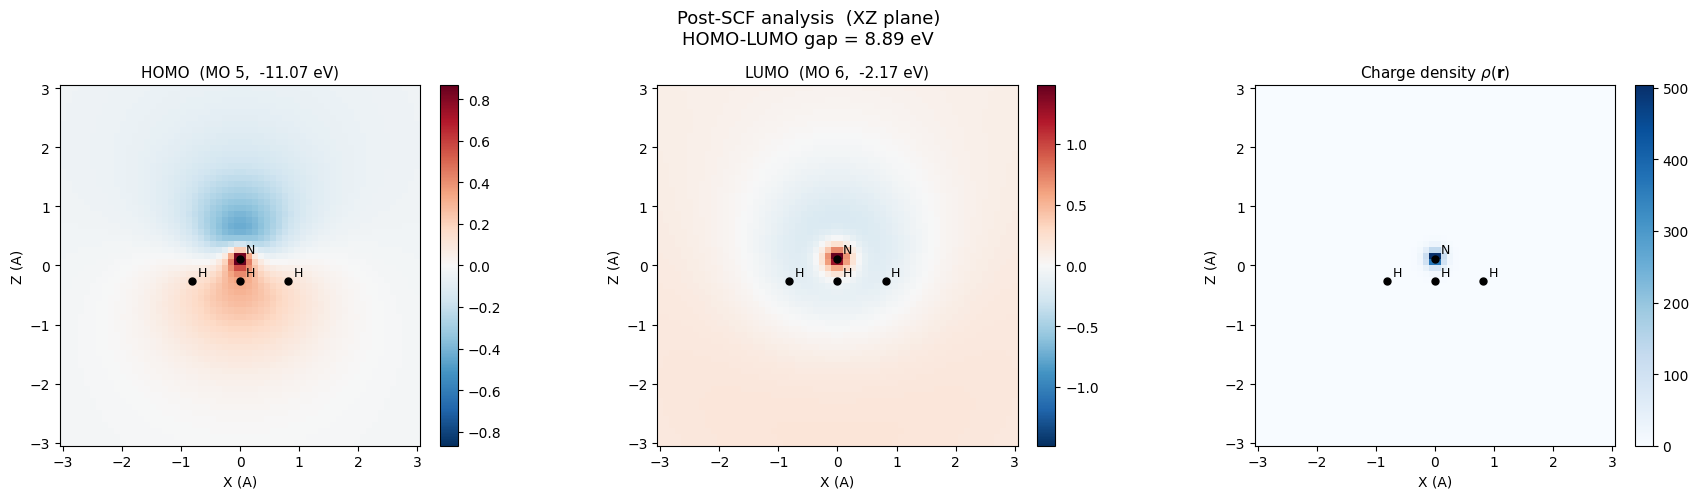

In [23]:
# ---------------------------------------------------------------------------
# Visualisation: HOMO, LUMO, and converged charge density
# ---------------------------------------------------------------------------

def _eval_mo_on_plane(mo_coeffs, basis_functions, plane, axis1, axis2, fixed_val):
    # Evaluate psi(r) = sum_mu C_mu phi_mu(r) on a 2-D grid.
    # fixed_val: the coordinate held constant (the axis perpendicular to the plane).
    vals = np.zeros(axis1.shape)
    it   = np.nditer([axis1, axis2], flags=['multi_index'])
    while not it.finished:
        idx  = it.multi_index
        a1, a2 = float(it[0]), float(it[1])
        if plane == 'xy':
            pt = [a1, a2, fixed_val]
        elif plane == 'xz':
            pt = [a1, fixed_val, a2]
        else:                            # 'yz'
            pt = [fixed_val, a1, a2]
        psi = sum(c * bf.evaluate(pt) for c, bf in zip(mo_coeffs, basis_functions))
        vals[idx] = psi
        it.iternext()
    return vals


def _eval_density_on_plane(density_matrix, basis_functions, plane, axis1, axis2, fixed_val):
    # Evaluate rho(r) = sum_mn P_mn phi_m(r) phi_n(r) on a 2-D grid.
    n_basis = len(basis_functions)
    rho     = np.zeros(axis1.shape)
    it      = np.nditer([axis1, axis2], flags=['multi_index'])
    while not it.finished:
        idx  = it.multi_index
        a1, a2 = float(it[0]), float(it[1])
        if plane == 'xy':
            pt = [a1, a2, fixed_val]
        elif plane == 'xz':
            pt = [a1, fixed_val, a2]
        else:
            pt = [fixed_val, a1, a2]
        phi_vals = np.array([bf.evaluate(pt) for bf in basis_functions])
        rho[idx] = phi_vals @ density_matrix @ phi_vals
        it.iternext()
    return rho


def plot_homo_lumo_density(converged_mo_coeffs, converged_density_matrix,
                            basis_functions, atoms, orbital_energies_Ha,
                            n_electrons, plane='xz',
                            x_range=(-3, 3), y_range=(-3, 3), n_pts=60):
    # Plot HOMO, LUMO, and charge density on a 2-D coordinate plane.
    #
    # Parameters
    #   converged_mo_coeffs      : ndarray (n_basis, n_basis)  from solve_roothaan_hall
    #   converged_density_matrix : ndarray (n_basis, n_basis)  P from SCF
    #   basis_functions          : list of GaussianBasisFunction
    #   atoms                    : list of Atom
    #   orbital_energies_Ha      : ndarray (n_basis,)  KS eigenvalues
    #   n_electrons              : int
    #   plane                    : 'xy' | 'xz' | 'yz'
    #   x_range, y_range         : axis extents (Angstrom)
    #   n_pts                    : grid resolution

    n_occ    = n_electrons // 2
    homo_idx = n_occ - 1
    lumo_idx = n_occ

    ax1, ax2  = generate_meshgrid(plane, x_range, y_range, n_pts)
    ax_labels = {'xy': ('X (A)', 'Y (A)'),
                 'xz': ('X (A)', 'Z (A)'),
                 'yz': ('Y (A)', 'Z (A)')}[plane]

    # Midpoint of molecule for the fixed coordinate
    center = np.mean([a.position for a in atoms], axis=0)
    if plane == 'xy':   fixed_val = center[2]
    elif plane == 'xz': fixed_val = center[1]
    else:               fixed_val = center[0]

    # Evaluate HOMO, LUMO, charge density
    homo_vals  = _eval_mo_on_plane(converged_mo_coeffs[:, homo_idx], basis_functions,
                                    plane, ax1, ax2, fixed_val)
    lumo_vals  = _eval_mo_on_plane(converged_mo_coeffs[:, lumo_idx], basis_functions,
                                    plane, ax1, ax2, fixed_val)
    rho_vals   = _eval_density_on_plane(converged_density_matrix, basis_functions,
                                         plane, ax1, ax2, fixed_val)

    e_homo_eV = orbital_energies_Ha[homo_idx] * 27.2114
    e_lumo_eV = orbital_energies_Ha[lumo_idx] * 27.2114
    gap_eV    = e_lumo_eV - e_homo_eV

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Post-SCF analysis  ({plane.upper()} plane)\n"
                 f"HOMO-LUMO gap = {gap_eV:.2f} eV", fontsize=13)

    panels = [
        (homo_vals, f'HOMO  (MO {homo_idx+1},  {e_homo_eV:.2f} eV)', 'RdBu_r'),
        (lumo_vals, f'LUMO  (MO {lumo_idx+1},  {e_lumo_eV:.2f} eV)', 'RdBu_r'),
        (rho_vals,  r'Charge density $\rho(\mathbf{r})$',             'Blues'),
    ]

    for ax, (data, title, cmap) in zip(axes, panels):
        # Symmetric colour scale for MOs, one-sided for density
        if cmap == 'RdBu_r':
            vmax = max(abs(data.min()), abs(data.max()))
            vmin = -vmax
        else:
            vmin, vmax = 0, data.max()

        im = ax.pcolormesh(ax1, ax2, data, shading='auto',
                           cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel(ax_labels[0]); ax.set_ylabel(ax_labels[1])
        ax.set_aspect('equal')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Mark nuclear positions projected onto the plane
        for atom in atoms:
            if plane == 'xy':   ax_pos = (atom.position[0], atom.position[1])
            elif plane == 'xz': ax_pos = (atom.position[0], atom.position[2])
            else:               ax_pos = (atom.position[1], atom.position[2])
            ax.plot(*ax_pos, 'ko', markersize=5)
            ax.annotate(atom.element, ax_pos, textcoords='offset points',
                        xytext=(4, 4), fontsize=9, color='black')

    plt.tight_layout()
    plt.show()


def plot_homo_lumo_orbital_diagram(orbital_energies_Ha, n_electrons):
    # Orbital energy level diagram showing HOMO, LUMO and the gap.
    valid     = ~np.isnan(orbital_energies_Ha)
    e_eV      = orbital_energies_Ha[valid] * 27.2114
    n_levels  = len(e_eV)
    n_occ     = n_electrons // 2
    homo_idx  = n_occ - 1
    lumo_idx  = n_occ

    fig, ax = plt.subplots(figsize=(5, max(6, n_levels * 0.7)))
    ax.set_title("KS Orbital Energies", fontsize=12)

    for i, e in enumerate(e_eV):
        color  = '#2166ac' if i < n_occ else '#d6604d'
        lw     = 2.5
        ax.hlines(e, 0.2, 0.8, colors=color, linewidths=lw)
        label  = f"MO {i+1}:  {e:.2f} eV"
        if i == homo_idx: label += "  HOMO"
        if i == lumo_idx: label += "  LUMO"
        ax.text(0.85, e, label, va='center', fontsize=9,
                color=color, fontweight='bold' if i in (homo_idx, lumo_idx) else 'normal')
        if i < n_occ:
            # Indicate double occupancy with up/down arrows
            ax.annotate('', xy=(0.42, e + 0.05), xytext=(0.42, e - 0.6),
                        arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))
            ax.annotate('', xy=(0.58, e - 0.05), xytext=(0.58, e + 0.6),
                        arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))

    # HOMO-LUMO gap bracket
    gap = e_eV[lumo_idx] - e_eV[homo_idx]
    mid = (e_eV[homo_idx] + e_eV[lumo_idx]) / 2
    ax.annotate('', xy=(0.1, e_eV[lumo_idx]), xytext=(0.1, e_eV[homo_idx]),
                arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))
    ax.text(0.0, mid, f'gap\n{gap:.2f} eV', ha='right', va='center',
            fontsize=9, color='green')

    ax.set_xlim(-0.3, 2.0)
    ax.set_ylabel("Energy (eV)")
    ax.set_xticks([])
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    plt.tight_layout()
    plt.show()


# ── Run the visualisations ───────────────────────────────────────────────────
print("Plotting orbital energy diagram...")
plot_homo_lumo_orbital_diagram(orbital_energies_Ha, num_electrons)

print("Plotting HOMO, LUMO and charge density (xz plane)...")
plot_homo_lumo_density(
    converged_mo_coeffs       = converged_mo_coeffs,
    converged_density_matrix  = converged_density,
    basis_functions           = atomic_orbitals,
    atoms                     = atoms,
    orbital_energies_Ha       = orbital_energies_Ha,
    n_electrons               = num_electrons,
    plane                     = 'xz',
    x_range                   = (-3, 3),
    y_range                   = (-3, 3),
    n_pts                     = 60,
)
